# EEEM068 - Prompt Tuning CLIP: CoCoOp vs ProMIM
## Few-Shot Comparison (1 / 4 / 8 / 16 shots)

**Notebook structure**
1. Install dependencies
2. Imports & device setup
3. Find & Extract Dataset & Load CLIP & DataLoaders
   - 3b. Reusable Dataset Loader
4. Shared helper functions
5. CoCoOp - Conditional Context Optimisation (official settings)
6. ProMIM - Masked Image Modelling for Conditional Prompt Learning
7. Few-shot sampler utility
8. Training & evaluation functions
9. Run experiments: 1 / 4 / 8 / 16-shot on current dataset (Base-to-New Generalization)
10. Figure 4 - ProMIM vs CoCoOp improvement (16-shot)
11. Method Comparison Chart (line chart / bar chart / loss curves / summary table)
12. Text-to-image attention map visualisation (occlusion sensitivity)
13. Hyperparameter ablation (mask ratio & lambda)
14. Embedding Space Visualisation - PCA, t-SNE, UMAP


## 0. Install Dependencies

> CoCoOp and ProMIM are implemented from scratch in this notebook using  
> only standard PyTorch + the OpenAI CLIP package.  
> `umap-learn` is needed only for Section 13.


In [14]:
# Windows dependencies
# CLIP (OpenAI) - only non-standard dependency for Sections 1-12
!pip install -q git+https://github.com/openai/CLIP.git
# umap-learn - needed for Section 13 (Embedding Space Visualisation)
!pip install -q umap-learn
print('All dependencies installed.')

# Linux-Lab Dependencies
# import sys
# !{sys.executable} -m pip install --break-system-packages torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !{sys.executable} -m pip install --break-system-packages git+https://github.com/openai/CLIP.git
# !{sys.executable} -m pip install --break-system-packages umap-learn
# import os
# # Set your desired root folder
# os.chdir("/user/HS402/lg01302/Documents")
# # Verify the change
# print(os.getcwd())

All dependencies installed.


## 1. Official Custom Prompt Templates

### Available: https://github.com/KaiyangZhou/CoOp/blob/main/trainers/zsclip.py

In [15]:
# Official hand-crafted templates from CoOp/CLIP for the 11 base datasets
CUSTOM_TEMPLATES = {
    "caltech101": "a photo of a {}.",
    "oxford_pets": "a photo of a {}, a type of pet.",
    "stanford_cars": "a photo of a {}.",
    "flowers102": "a photo of a {}, a type of flower.",
    "food101": "a photo of {}, a type of food.",
    "fgvc_aircraft": "a photo of a {}, a type of aircraft.",
    "sun397": "a photo of a {}.",
    "dtd": "{} texture.",
    "eurosat": "a centered satellite photo of {}.",
    "ucf101": "a photo of a person doing {}.",
    "imagenet": "a photo of a {}."
}

def get_template(ds_name):
    return CUSTOM_TEMPLATES.get(ds_name.lower(), "a photo of a {}.")


## 2. Imports & Device Setup

In [16]:
import os
import json
import time
import re
import shutil
import zipfile

import numpy as np
import torch
import clip
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torchvision import datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected - Runtime > Change runtime type > T4 GPU")
from PIL import Image

class FGVCAircraftDataset(torch.utils.data.Dataset):
    """FGVC Aircraft - flat images/ dir, official variant txt splits on Drive.
    Each line format: '{image_id} {class_name}'  (class_name may contain spaces).
    options: 'fgvc_aircraft'
    """
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir, self.samples, self.transform = img_dir, samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img) if self.transform else img, label

class GenericJSONSplitDataset(torch.utils.data.Dataset):
    """Generic dataset loader that uses a JSON file for splits.
    Handles flat or nested directories depending on fname in the split.
    options: 'eurosat', 'caltech101', 'oxford_pets', 'dtd', 'flowers102', 'food101', 'stanford_cars', 'ucf101'
    """
    def __init__(self, img_dir, samples, transform=None):
        self.img_dir = img_dir
        self.samples = samples
        self.transform = transform
        
    def __len__(self): return len(self.samples)
    
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img_path = os.path.join(self.img_dir, fname)
        if not os.path.exists(img_path):
            fallback_path = os.path.join(self.img_dir, os.path.basename(fname))
            if os.path.exists(fallback_path):
                img_path = fallback_path
        
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


Using device: cuda


## 3. Find & Extract Dataset & Load CLIP

> **Before running:** in Google Drive go to *Shared with me -> AML Dataset
> -> Organise -> Add shortcut -> My Drive*, then run this cell.

- `DATASET_NAME` - change this one line to switch datasets
- `CLASSES` provides human-readable names for CLIP text encoding
- `clip_model` is loaded as ViT-B/16 (frozen throughout)

In [17]:
# ============================================================================
# CHANGE ONLY THIS LINE to switch datasets
DATASET_NAME = 'flowers102'
# options:
# 'eurosat', 'caltech101', 'oxford_pets', 'dtd', 'flowers102', 
# 'food101', 'fgvc_aircraft', 'stanford_cars', 'ucf101'
# ============================================================================

# Per-dataset config
# local_subpath : folder inside DATASETS_DIR that contains the dataset zip
# classes : human-readable class names in ImageFolder alphabetical order (used for CLIP text encoding - must match folder sort order)
# folder_map : {folder_name: readable_name} for reference / debugging

DATASET_CONFIGS = {

    'eurosat': {
        'local_subpath': 'EuroSAT',
        'split_json': 'split_zhou_EuroSAT.json',
        'classes': [
            'Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway',
            'Industrial', 'Pasture', 'Permanent Crop', 'Residential',
            'River', 'Sea Lake',
        ],
        'folder_map': {
            'AnnualCrop': 'Annual Crop', 'Forest': 'Forest',
            'HerbaceousVegetation': 'Herbaceous Vegetation', 'Highway': 'Highway',
            'Industrial': 'Industrial', 'Pasture': 'Pasture',
            'PermanentCrop': 'Permanent Crop', 'Residential': 'Residential',
            'River': 'River', 'SeaLake': 'Sea Lake',
        },
    },

    'caltech101': {
        'local_subpath': 'Caltech101',
        'split_json': 'split_zhou_Caltech101.json',
        'classes': [
            'background', 'off-center face', 'centered face', 'leopard',
            'motorbike', 'accordion', 'airplane', 'anchor', 'ant', 'barrel',
            'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus',
            'buddha', 'butterfly', 'camera', 'cannon', 'side of a car',
            'ceiling fan', 'cellphone', 'chair', 'chandelier',
            'body of a cougar cat', 'face of a cougar cat', 'crab', 'crayfish',
            'crocodile', 'head of a crocodile', 'cup', 'dalmatian',
            'dollar bill', 'dolphin', 'dragonfly', 'electric guitar', 'elephant',
            'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'head of a flamingo',
            'garfield', 'gerenuk', 'gramophone', 'grand piano', 'hawksbill',
            'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline skate',
            'joshua tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama',
            'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome',
            'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda',
            'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino',
            'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion',
            'sea horse', 'snoopy (cartoon beagle)', 'soccer ball', 'stapler',
            'starfish', 'stegosaurus', 'stop sign', 'strawberry', 'sunflower',
            'tick', 'trilobite', 'umbrella', 'watch', 'water lilly',
            'wheelchair', 'wild cat', 'windsor chair', 'wrench',
            'yin and yang symbol',
        ],
        'folder_map': {
            'BACKGROUND_Google': 'background', 'Faces': 'off-center face',
            'Faces_easy': 'centered face', 'Leopards': 'leopard',
            'Motorbikes': 'motorbike', 'accordion': 'accordion',
            'airplanes': 'airplane', 'anchor': 'anchor', 'ant': 'ant',
            'barrel': 'barrel', 'bass': 'bass', 'beaver': 'beaver',
            'binocular': 'binocular', 'bonsai': 'bonsai', 'brain': 'brain',
            'brontosaurus': 'brontosaurus', 'buddha': 'buddha',
            'butterfly': 'butterfly', 'camera': 'camera', 'cannon': 'cannon',
            'car_side': 'side of a car', 'ceiling_fan': 'ceiling fan',
            'cellphone': 'cellphone', 'chair': 'chair', 'chandelier': 'chandelier',
            'cougar_body': 'body of a cougar cat', 'cougar_face': 'face of a cougar cat',
            'crab': 'crab', 'crayfish': 'crayfish', 'crocodile': 'crocodile',
            'crocodile_head': 'head of a crocodile', 'cup': 'cup',
            'dalmatian': 'dalmatian', 'dollar_bill': 'dollar bill',
            'dolphin': 'dolphin', 'dragonfly': 'dragonfly',
            'electric_guitar': 'electric guitar', 'elephant': 'elephant',
            'emu': 'emu', 'euphonium': 'euphonium', 'ewer': 'ewer',
            'ferry': 'ferry', 'flamingo': 'flamingo',
            'flamingo_head': 'head of a flamingo', 'garfield': 'garfield',
            'gerenuk': 'gerenuk', 'gramophone': 'gramophone',
            'grand_piano': 'grand piano', 'hawksbill': 'hawksbill',
            'headphone': 'headphone', 'hedgehog': 'hedgehog',
            'helicopter': 'helicopter', 'ibis': 'ibis',
            'inline_skate': 'inline skate', 'joshua_tree': 'joshua tree',
            'kangaroo': 'kangaroo', 'ketch': 'ketch', 'lamp': 'lamp',
            'laptop': 'laptop', 'llama': 'llama', 'lobster': 'lobster',
            'lotus': 'lotus', 'mandolin': 'mandolin', 'mayfly': 'mayfly',
            'menorah': 'menorah', 'metronome': 'metronome', 'minaret': 'minaret',
            'nautilus': 'nautilus', 'octopus': 'octopus', 'okapi': 'okapi',
            'pagoda': 'pagoda', 'panda': 'panda', 'pigeon': 'pigeon',
            'pizza': 'pizza', 'platypus': 'platypus', 'pyramid': 'pyramid',
            'revolver': 'revolver', 'rhino': 'rhino', 'rooster': 'rooster',
            'saxophone': 'saxophone', 'schooner': 'schooner',
            'scissors': 'scissors', 'scorpion': 'scorpion',
            'sea_horse': 'sea horse', 'snoopy': 'snoopy (cartoon beagle)',
            'soccer_ball': 'soccer ball', 'stapler': 'stapler',
            'starfish': 'starfish', 'stegosaurus': 'stegosaurus',
            'stop_sign': 'stop sign', 'strawberry': 'strawberry',
            'sunflower': 'sunflower', 'tick': 'tick', 'trilobite': 'trilobite',
            'umbrella': 'umbrella', 'watch': 'watch', 'water_lilly': 'water lilly',
            'wheelchair': 'wheelchair', 'wild_cat': 'wild cat',
            'windsor_chair': 'windsor chair', 'wrench': 'wrench',
            'yin_yang': 'yin and yang symbol',
        },
    },

    'oxford_pets': {
        'local_subpath': 'OxfordPets',
        'split_json': 'split_zhou_OxfordPets.json',
        'classes': [
            'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
            'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
            'Siamese', 'Sphynx', 'american bulldog', 'american pit bull terrier',
            'basset hound', 'beagle', 'boxer', 'chihuahua', 'english cocker spaniel',
            'english setter', 'german shorthaired', 'great pyrenees', 'havanese',
            'japanese chin', 'keeshond', 'leonberger', 'miniature pinscher',
            'newfoundland', 'pomeranian', 'pug', 'saint bernard', 'samoyed',
            'scottish terrier', 'shiba inu', 'staffordshire bull terrier',
            'wheaten terrier', 'yorkshire terrier',
        ],
        'folder_map': {
            'Abyssinian': 'Abyssinian', 'Bengal': 'Bengal', 'Birman': 'Birman',
            'Bombay': 'Bombay', 'British_Shorthair': 'British Shorthair',
            'Egyptian_Mau': 'Egyptian Mau', 'Maine_Coon': 'Maine Coon',
            'Persian': 'Persian', 'Ragdoll': 'Ragdoll', 'Russian_Blue': 'Russian Blue',
            'Siamese': 'Siamese', 'Sphynx': 'Sphynx',
            'american_bulldog': 'american bulldog',
            'american_pit_bull_terrier': 'american pit bull terrier',
            'basset_hound': 'basset hound', 'beagle': 'beagle', 'boxer': 'boxer',
            'chihuahua': 'chihuahua', 'english_cocker_spaniel': 'english cocker spaniel',
            'english_setter': 'english setter', 'german_shorthaired': 'german shorthaired',
            'great_pyrenees': 'great pyrenees', 'havanese': 'havanese',
            'japanese_chin': 'japanese chin', 'keeshond': 'keeshond',
            'leonberger': 'leonberger', 'miniature_pinscher': 'miniature pinscher',
            'newfoundland': 'newfoundland', 'pomeranian': 'pomeranian', 'pug': 'pug',
            'saint_bernard': 'saint bernard', 'samoyed': 'samoyed',
            'scottish_terrier': 'scottish terrier', 'shiba_inu': 'shiba inu',
            'staffordshire_bull_terrier': 'staffordshire bull terrier',
            'wheaten_terrier': 'wheaten terrier', 'yorkshire_terrier': 'yorkshire terrier',
        },
    },

    'flowers102': {
        'local_subpath': 'Flowers102',
        'split_json':     'split_zhou_OxfordFlowers.json',
        'images_subpath': 'jpg',          # flat dir inside extracted 102flowers.tgz
        'classes': [
            'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells',
            'sweet pea', 'english marigold', 'tiger lily', 'moon orchid',
            'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon',
            "colt's foot", 'king protea', 'spear thistle', 'yellow iris',
            'globe flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
            'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary',
            'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers',
            'stemless gentian', 'artichoke', 'sweet william', 'carnation',
            'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly',
            'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip',
            'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
            'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy',
            'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower',
            'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
            'pink and yellow dahlia', 'cautleya spicata', 'japanese anemone',
            'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
            'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania',
            'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory',
            'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
            'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow',
            'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum',
            'bee balm', 'air plant', 'foxglove', 'bougainvillea', 'camellia',
            'mallow', 'mexican petunia', 'bromelia', 'blanket flower',
            'trumpet creeper', 'blackberry lily',
        ],
        'folder_map': {},   # not used - splits come from split_json
    },

    'fgvc_aircraft': {
        'local_subpath':    'FGVCAircraft',
        'images_subpath':   'images',     # flat jpg dir inside extracted zip
        'annotation_level': 'variant',    # drives which txt files are read can be 'variant', 'manufacturer', 'family'
        'classes': [
            '707-320', '727-200', '737-200', '737-300', '737-400', '737-500',
            '737-600', '737-700', '737-800', '737-900', '747-100', '747-200',
            '747-300', '747-400', '757-200', '757-300', '767-200', '767-300',
            '767-400', '777-200', '777-300', 'A300B4', 'A310', 'A318', 'A319',
            'A320', 'A321', 'A330-200', 'A330-300', 'A340-200', 'A340-300',
            'A340-500', 'A340-600', 'A380', 'ATR-42', 'ATR-72', 'An-12',
            'BAE 146-200', 'BAE 146-300', 'BAE-125', 'Beechcraft 1900',
            'Boeing 717', 'C-130', 'C-47', 'CRJ-200', 'CRJ-700', 'CRJ-900',
            'Cessna 172', 'Cessna 208', 'Cessna 525', 'Cessna 560',
            'Challenger 600', 'DC-10', 'DC-3', 'DC-6', 'DC-8', 'DC-9-30',
            'DH-82', 'DHC-1', 'DHC-6', 'DHC-8-100', 'DHC-8-300', 'DR-400',
            'Dornier 328', 'E-170', 'E-190', 'E-195', 'EMB-120', 'ERJ 135',
            'ERJ 145', 'Embraer Legacy 600', 'Eurofighter Typhoon', 'F-16A/B',
            'F/A-18', 'Falcon 2000', 'Falcon 900', 'Fokker 100', 'Fokker 50',
            'Fokker 70', 'Global Express', 'Gulfstream IV', 'Gulfstream V',
            'Hawk T1', 'Il-76', 'L-1011', 'MD-11', 'MD-80', 'MD-87', 'MD-90',
            'Metroliner', 'Model B200', 'PA-28', 'SR-20', 'Saab 2000',
            'Saab 340', 'Spitfire', 'Tornado', 'Tu-134', 'Tu-154', 'Yak-42',
        ],
        'folder_map': {},   # not used - splits come from images_variant_*.txt on Drive
    },

    'food101': {
        'local_subpath':  'Food101',
        'split_json':     'split_zhou_Food101.json',
        'images_subpath': 'food-101/images',  # nested after tar.gz extraction
        'classes': [
            'apple pie', 'baby back ribs', 'baklava', 'beef carpaccio', 'beef tartare',
            'beet salad', 'beignets', 'bibimbap', 'bread pudding', 'breakfast burrito', 'bruschetta',
            'caesar salad', 'cannoli', 'caprese salad', 'carrot cake', 'ceviche', 'cheese plate',
            'cheesecake', 'chicken curry', 'chicken quesadilla', 'chicken wings', 'chocolate cake',
            'chocolate mousse', 'churros', 'clam chowder', 'club sandwich', 'crab cakes', 'creme brulee',
            'croque madame', 'cup cakes', 'deviled eggs', 'donuts', 'dumplings', 'edamame', 'eggs benedict',
            'escargots', 'falafel', 'filet mignon', 'fish and chips', 'foie gras', 'french fries',
            'french onion soup', 'french toast', 'fried calamari', 'fried rice', 'frozen yogurt', 'garlic bread',
            'gnocchi', 'greek salad', 'grilled cheese sandwich', 'grilled salmon', 'guacamole', 'gyoza',
            'hamburger', 'hot and sour soup', 'hot dog', 'huevos rancheros', 'hummus', 'ice cream', 'lasagna',
            'lobster bisque', 'lobster roll sandwich', 'macaroni and cheese', 'macarons', 'miso soup', 'mussels',
            'nachos', 'omelette', 'onion rings', 'oysters', 'pad thai', 'paella', 'pancakes', 'panna cotta',
            'peking duck', 'pho', 'pizza', 'pork chop', 'poutine', 'prime rib', 'pulled pork sandwich', 'ramen',
            'ravioli', 'red velvet cake', 'risotto', 'samosa', 'sashimi', 'scallops', 'seaweed salad', 'shrimp and grits',
            'spaghetti bolognese', 'spaghetti carbonara', 'spring rolls', 'steak', 'strawberry shortcake', 'sushi', 'tacos',
            'takoyaki', 'tiramisu', 'tuna tartare', 'waffles'
        ],
        'folder_map': {
            'apple_pie': 'apple pie', 'baby_back_ribs': 'baby back ribs', 'baklava': 'baklava', 'beef_carpaccio': 'beef carpaccio',
            'beef_tartare': 'beef tartare', 'beet_salad': 'beet salad', 'beignets': 'beignets', 'bibimbap': 'bibimbap',
            'bread_pudding': 'bread pudding', 'breakfast_burrito': 'breakfast burrito', 'bruschetta': 'bruschetta',
            'caesar_salad': 'caesar salad', 'cannoli': 'cannoli', 'caprese_salad': 'caprese salad', 'carrot_cake': 'carrot cake',
            'ceviche': 'ceviche', 'cheese_plate': 'cheese plate', 'cheesecake': 'cheesecake', 'chicken_curry': 'chicken curry',
            'chicken_quesadilla': 'chicken quesadilla', 'chicken_wings': 'chicken wings', 'chocolate_cake': 'chocolate cake',
            'chocolate_mousse': 'chocolate mousse', 'churros': 'churros', 'clam_chowder': 'clam chowder', 'club_sandwich': 'club sandwich',
            'crab_cakes': 'crab cakes', 'creme_brulee': 'creme brulee', 'croque_madame': 'croque madame', 'cup_cakes': 'cup cakes',
            'deviled_eggs': 'deviled eggs', 'donuts': 'donuts', 'dumplings': 'dumplings', 'edamame': 'edamame', 'eggs_benedict': 'eggs benedict',
            'escargots': 'escargots', 'falafel': 'falafel', 'filet_mignon': 'filet mignon', 'fish_and_chips': 'fish and chips',
            'foie_gras': 'foie gras', 'french_fries': 'french fries', 'french_onion_soup': 'french onion soup', 'french_toast': 'french toast',
            'fried_calamari': 'fried calamari', 'fried_rice': 'fried rice', 'frozen_yogurt': 'frozen yogurt', 'garlic_bread': 'garlic bread',
            'gnocchi': 'gnocchi', 'greek_salad': 'greek salad', 'grilled_cheese_sandwich': 'grilled cheese sandwich',
            'grilled_salmon': 'grilled salmon', 'guacamole': 'guacamole', 'gyoza': 'gyoza', 'hamburger': 'hamburger',
            'hot_and_sour_soup': 'hot and sour soup', 'hot_dog': 'hot dog', 'huevos_rancheros': 'huevos rancheros', 'hummus': 'hummus',
            'ice_cream': 'ice cream', 'lasagna': 'lasagna', 'lobster_bisque': 'lobster bisque', 'lobster_roll_sandwich': 'lobster roll sandwich',
            'macaroni_and_cheese': 'macaroni and cheese', 'macarons': 'macarons', 'miso_soup': 'miso soup', 'mussels': 'mussels', 'nachos': 'nachos',
            'omelette': 'omelette', 'onion_rings': 'onion rings', 'oysters': 'oysters', 'pad_thai': 'pad thai', 'paella': 'paella',
            'pancakes': 'pancakes', 'panna_cotta': 'panna cotta', 'peking_duck': 'peking duck', 'pho': 'pho', 'pizza': 'pizza',
            'pork_chop': 'pork chop', 'poutine': 'poutine', 'prime_rib': 'prime rib', 'pulled_pork_sandwich': 'pulled pork sandwich',
            'ramen': 'ramen', 'ravioli': 'ravioli', 'red_velvet_cake': 'red velvet cake', 'risotto': 'risotto', 'samosa': 'samosa',
            'sashimi': 'sashimi', 'scallops': 'scallops', 'seaweed_salad': 'seaweed salad', 'shrimp_and_grits': 'shrimp and grits',
            'spaghetti_bolognese': 'spaghetti bolognese', 'spaghetti_carbonara': 'spaghetti carbonara', 'spring_rolls': 'spring rolls',
            'steak': 'steak', 'strawberry_shortcake': 'strawberry shortcake', 'sushi': 'sushi', 'tacos': 'tacos', 'takoyaki': 'takoyaki',
            'tiramisu': 'tiramisu', 'tuna_tartare': 'tuna tartare', 'waffles': 'waffles'
        },
    },

    'stanford_cars': {
        'local_subpath': 'StanfordCars',
        'split_json':    'split_zhou_StanfordCars.json',
        # No images_subpath - filenames in JSON already include cars_train/ or cars_test/
        # so img_dir is set to EXTRACTED_DATASET_PATH directly after extraction
        'classes': [
            'AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008',
            'Acura TSX Sedan 2012', 'Acura Integra Type R 2001', 'Acura ZDX Hatchback 2012',
            'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012',
            'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi RS 4 Convertible 2008',
            'Audi A5 Coupe 2012', 'Audi TTS Coupe 2012', 'Audi R8 Coupe 2012', 'Audi V8 Sedan 1994', 'Audi 100 Sedan 1994',
            'Audi 100 Wagon 1994', 'Audi TT Hatchback 2011', 'Audi S6 Sedan 2011', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012',
            'Audi S4 Sedan 2012', 'Audi S4 Sedan 2007', 'Audi TT RS Coupe 2012', 'BMW ActiveHybrid 5 Sedan 2012',
            'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012',
            'BMW 6 Series Convertible 2007', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010',
            'BMW M6 Convertible 2010', 'BMW X3 SUV 2012', 'BMW Z4 Convertible 2012', 'Bentley Continental Supersports Conv. Convertible 2012',
            'Bentley Arnage Sedan 2009', 'Bentley Mulsanne Sedan 2011', 'Bentley Continental GT Coupe 2012',
            'Bentley Continental GT Coupe 2007', 'Bentley Continental Flying Spur Sedan 2007', 'Bugatti Veyron 16.4 Convertible 2009',
            'Bugatti Veyron 16.4 Coupe 2009', 'Buick Regal GS 2012', 'Buick Rainier SUV 2007', 'Buick Verano Sedan 2012',
            'Buick Enclave SUV 2012', 'Cadillac CTS-V Sedan 2012', 'Cadillac SRX SUV 2012', 'Cadillac Escalade EXT Crew Cab 2007',
            'Chevrolet Silverado 1500 Hybrid Crew Cab 2012', 'Chevrolet Corvette Convertible 2012', 'Chevrolet Corvette ZR1 2012',
            'Chevrolet Corvette Ron Fellows Edition Z06 2007', 'Chevrolet Traverse SUV 2012', 'Chevrolet Camaro Convertible 2012',
            'Chevrolet HHR SS 2010', 'Chevrolet Impala Sedan 2007', 'Chevrolet Tahoe Hybrid SUV 2012', 'Chevrolet Sonic Sedan 2012',
            'Chevrolet Express Cargo Van 2007', 'Chevrolet Avalanche Crew Cab 2012', 'Chevrolet Cobalt SS 2010',
            'Chevrolet Malibu Hybrid Sedan 2010', 'Chevrolet TrailBlazer SS 2009', 'Chevrolet Silverado 2500HD Regular Cab 2012',
            'Chevrolet Silverado 1500 Classic Extended Cab 2007', 'Chevrolet Express Van 2007', 'Chevrolet Monte Carlo Coupe 2007',
            'Chevrolet Malibu Sedan 2007', 'Chevrolet Silverado 1500 Extended Cab 2012', 'Chevrolet Silverado 1500 Regular Cab 2012',
            'Chrysler Aspen SUV 2009', 'Chrysler Sebring Convertible 2010', 'Chrysler Town and Country Minivan 2012', 'Chrysler 300 SRT-8 2010',
            'Chrysler Crossfire Convertible 2008', 'Chrysler PT Cruiser Convertible 2008', 'Daewoo Nubira Wagon 2002', 'Dodge Caliber Wagon 2012',
            'Dodge Caliber Wagon 2007', 'Dodge Caravan Minivan 1997', 'Dodge Ram Pickup 3500 Crew Cab 2010', 'Dodge Ram Pickup 3500 Quad Cab 2009',
            'Dodge Sprinter Cargo Van 2009', 'Dodge Journey SUV 2012', 'Dodge Dakota Crew Cab 2010', 'Dodge Dakota Club Cab 2007',
            'Dodge Magnum Wagon 2008', 'Dodge Challenger SRT8 2011', 'Dodge Durango SUV 2012', 'Dodge Durango SUV 2007', 'Dodge Charger Sedan 2012',
            'Dodge Charger SRT-8 2009', 'Eagle Talon Hatchback 1998', 'FIAT 500 Abarth 2012', 'FIAT 500 Convertible 2012', 'Ferrari FF Coupe 2012',
            'Ferrari California Convertible 2012', 'Ferrari 458 Italia Convertible 2012', 'Ferrari 458 Italia Coupe 2012', 'Fisker Karma Sedan 2012',
            'Ford F-450 Super Duty Crew Cab 2012', 'Ford Mustang Convertible 2007', 'Ford Freestar Minivan 2007', 'Ford Expedition EL SUV 2009',
            'Ford Edge SUV 2012', 'Ford Ranger SuperCab 2011', 'Ford GT Coupe 2006', 'Ford F-150 Regular Cab 2012', 'Ford F-150 Regular Cab 2007',
            'Ford Focus Sedan 2007', 'Ford E-Series Wagon Van 2012', 'Ford Fiesta Sedan 2012', 'GMC Terrain SUV 2012', 'GMC Savana Van 2012',
            'GMC Yukon Hybrid SUV 2012', 'GMC Acadia SUV 2012', 'GMC Canyon Extended Cab 2012', 'Geo Metro Convertible 1993',
            'HUMMER H3T Crew Cab 2010', 'HUMMER H2 SUT Crew Cab 2009', 'Honda Odyssey Minivan 2012', 'Honda Odyssey Minivan 2007',
            'Honda Accord Coupe 2012', 'Honda Accord Sedan 2012', 'Hyundai Veloster Hatchback 2012', 'Hyundai Santa Fe SUV 2012',
            'Hyundai Tucson SUV 2012', 'Hyundai Veracruz SUV 2012', 'Hyundai Sonata Hybrid Sedan 2012', 'Hyundai Elantra Sedan 2007',
            'Hyundai Accent Sedan 2012', 'Hyundai Genesis Sedan 2012', 'Hyundai Sonata Sedan 2012', 'Hyundai Elantra Touring Hatchback 2012',
            'Hyundai Azera Sedan 2012', 'Infiniti G Coupe IPL 2012', 'Infiniti QX56 SUV 2011', 'Isuzu Ascender SUV 2008', 'Jaguar XK XKR 2012',
            'Jeep Patriot SUV 2012', 'Jeep Wrangler SUV 2012', 'Jeep Liberty SUV 2012', 'Jeep Grand Cherokee SUV 2012', 'Jeep Compass SUV 2012',
            'Lamborghini Reventon Coupe 2008', 'Lamborghini Aventador Coupe 2012', 'Lamborghini Gallardo LP 570-4 Superleggera 2012',
            'Lamborghini Diablo Coupe 2001', 'Land Rover Range Rover SUV 2012', 'Land Rover LR2 SUV 2012', 'Lincoln Town Car Sedan 2011',
            'MINI Cooper Roadster Convertible 2012', 'Maybach Landaulet Convertible 2012', 'Mazda Tribute SUV 2011', 'McLaren MP4-12C Coupe 2012',
            'Mercedes-Benz 300-Class Convertible 1993', 'Mercedes-Benz C-Class Sedan 2012', 'Mercedes-Benz SL-Class Coupe 2009',
            'Mercedes-Benz E-Class Sedan 2012', 'Mercedes-Benz S-Class Sedan 2012', 'Mercedes-Benz Sprinter Van 2012', 'Mitsubishi Lancer Sedan 2012',
            'Nissan Leaf Hatchback 2012', 'Nissan NV Passenger Van 2012', 'Nissan Juke Hatchback 2012', 'Nissan 240SX Coupe 1998',
            'Plymouth Neon Coupe 1999', 'Porsche Panamera Sedan 2012', 'Ram C/V Cargo Van Minivan 2012',
            'Rolls-Royce Phantom Drophead Coupe Convertible 2012', 'Rolls-Royce Ghost Sedan 2012', 'Rolls-Royce Phantom Sedan 2012',
            'Scion xD Hatchback 2012', 'Spyker C8 Convertible 2009', 'Spyker C8 Coupe 2009', 'Suzuki Aerio Sedan 2007',
            'Suzuki Kizashi Sedan 2012', 'Suzuki SX4 Hatchback 2012', 'Suzuki SX4 Sedan 2012', 'Tesla Model S Sedan 2012', 'Toyota Sequoia SUV 2012',
            'Toyota Camry Sedan 2012', 'Toyota Corolla Sedan 2012', 'Toyota 4Runner SUV 2012', 'Volkswagen Golf Hatchback 2012',
            'Volkswagen Golf Hatchback 1991', 'Volkswagen Beetle Hatchback 2012', 'Volvo C30 Hatchback 2012', 'Volvo 240 Sedan 1993',
            'Volvo XC90 SUV 2007', 'smart fortwo Convertible 2012'
        ],
        'folder_map': {},   # not used - label indices from JSON are used directly
    },

    'ucf101': {
        'local_subpath':  'UCF101',
        'split_json':     'split_zhou_UCF101.json',
        'images_subpath': 'UCF-101-midframes',
        'classes': [
            'Apply Eye Makeup', 'Apply Lipstick', 'Archery', 'Baby Crawling', 'Balance Beam', 'Band Marching', 'Baseball Pitch',
            'Basketball', 'Basketball Dunk', 'Bench Press', 'Biking', 'Billiards', 'Blow Dry Hair', 'Blowing Candles', 'Body Weight Squats',
            'Bowling', 'Boxing Punching Bag', 'Boxing Speed Bag', 'Breast Stroke', 'Brushing Teeth', 'Clean And Jerk', 'Cliff Diving',
            'Cricket Bowling', 'Cricket Shot', 'Cutting In Kitchen', 'Diving', 'Drumming', 'Fencing', 'Field Hockey Penalty',
            'Floor Gymnastics', 'Frisbee Catch', 'Front Crawl', 'Golf Swing', 'Haircut', 'Hammer Throw', 'Hammering', 'Hand Stand Pushups',
            'Handstand Walking', 'Head Massage', 'High Jump', 'Horse Race', 'Horse Riding', 'Hula Hoop', 'Ice Dancing', 'Javelin Throw',
            'Juggling Balls', 'Jump Rope', 'Jumping Jack', 'Kayaking', 'Knitting', 'Long Jump', 'Lunges', 'Military Parade', 'Mixing',
            'Mopping Floor', 'Nunchucks', 'Parallel Bars', 'Pizza Tossing', 'Playing Cello', 'Playing Daf', 'Playing Dhol', 'Playing Flute',
            'Playing Guitar', 'Playing Piano', 'Playing Sitar', 'Playing Tabla', 'Playing Violin', 'Pole Vault', 'Pommel Horse', 'Pull Ups',
            'Punch', 'Push Ups', 'Rafting', 'Rock Climbing Indoor', 'Rope Climbing', 'Rowing', 'Salsa Spin', 'Shaving Beard', 'Shotput',
            'Skate Boarding', 'Skiing', 'Skijet', 'Sky Diving', 'Soccer Juggling', 'Soccer Penalty', 'Still Rings', 'Sumo Wrestling', 'Surfing',
            'Swing', 'Table Tennis Shot', 'Tai Chi', 'Tennis Swing', 'Throw Discus', 'Trampoline Jumping', 'Typing', 'Uneven Bars',
            'Volleyball Spiking', 'Walking With Dog', 'Wall Pushups', 'Writing On Board', 'Yo Yo'
        ],
        'folder_map': {
            'Apply_Eye_Makeup': 'Apply Eye Makeup', 'Apply_Lipstick': 'Apply Lipstick', 'Archery': 'Archery', 'Baby_Crawling': 'Baby Crawling',
            'Balance_Beam': 'Balance Beam', 'Band_Marching': 'Band Marching', 'Baseball_Pitch': 'Baseball Pitch', 'Basketball': 'Basketball',
            'Basketball_Dunk': 'Basketball Dunk', 'Bench_Press': 'Bench Press', 'Biking': 'Biking', 'Billiards': 'Billiards',
            'Blow_Dry_Hair': 'Blow Dry Hair', 'Blowing_Candles': 'Blowing Candles', 'Body_Weight_Squats': 'Body Weight Squats', 'Bowling': 'Bowling',
            'Boxing_Punching_Bag': 'Boxing Punching Bag', 'Boxing_Speed_Bag': 'Boxing Speed Bag', 'Breast_Stroke': 'Breast Stroke',
            'Brushing_Teeth': 'Brushing Teeth', 'Clean_And_Jerk': 'Clean And Jerk', 'Cliff_Diving': 'Cliff Diving',
            'Cricket_Bowling': 'Cricket Bowling', 'Cricket_Shot': 'Cricket Shot', 'Cutting_In_Kitchen': 'Cutting In Kitchen', 'Diving': 'Diving',
            'Drumming': 'Drumming', 'Fencing': 'Fencing', 'Field_Hockey_Penalty': 'Field Hockey Penalty', 'Floor_Gymnastics': 'Floor Gymnastics',
            'Frisbee_Catch': 'Frisbee Catch', 'Front_Crawl': 'Front Crawl', 'Golf_Swing': 'Golf Swing', 'Haircut': 'Haircut',
            'Hammer_Throw': 'Hammer Throw', 'Hammering': 'Hammering', 'Hand_Stand_Pushups': 'Hand Stand Pushups',
            'Handstand_Walking': 'Handstand Walking', 'Head_Massage': 'Head Massage', 'High_Jump': 'High Jump', 'Horse_Race': 'Horse Race',
            'Horse_Riding': 'Horse Riding', 'Hula_Hoop': 'Hula Hoop', 'Ice_Dancing': 'Ice Dancing', 'Javelin_Throw': 'Javelin Throw',
            'Juggling_Balls': 'Juggling Balls', 'Jump_Rope': 'Jump Rope', 'Jumping_Jack': 'Jumping Jack', 'Kayaking': 'Kayaking',
            'Knitting': 'Knitting', 'Long_Jump': 'Long Jump', 'Lunges': 'Lunges', 'Military_Parade': 'Military Parade', 'Mixing': 'Mixing',
            'Mopping_Floor': 'Mopping Floor', 'Nunchucks': 'Nunchucks', 'Parallel_Bars': 'Parallel Bars', 'Pizza_Tossing': 'Pizza Tossing',
            'Playing_Cello': 'Playing Cello', 'Playing_Daf': 'Playing Daf', 'Playing_Dhol': 'Playing Dhol', 'Playing_Flute': 'Playing Flute',
            'Playing_Guitar': 'Playing Guitar', 'Playing_Piano': 'Playing Piano', 'Playing_Sitar': 'Playing Sitar', 'Playing_Tabla': 'Playing Tabla',
            'Playing_Violin': 'Playing Violin', 'Pole_Vault': 'Pole Vault', 'Pommel_Horse': 'Pommel Horse', 'Pull_Ups': 'Pull Ups', 'Punch': 'Punch',
            'Push_Ups': 'Push Ups', 'Rafting': 'Rafting', 'Rock_Climbing_Indoor': 'Rock Climbing Indoor', 'Rope_Climbing': 'Rope Climbing',
            'Rowing': 'Rowing', 'Salsa_Spin': 'Salsa Spin', 'Shaving_Beard': 'Shaving Beard', 'Shotput': 'Shotput', 'Skate_Boarding': 'Skate Boarding',
            'Skiing': 'Skiing', 'Skijet': 'Skijet', 'Sky_Diving': 'Sky Diving', 'Soccer_Juggling': 'Soccer Juggling', 'Soccer_Penalty': 'Soccer Penalty',
            'Still_Rings': 'Still Rings', 'Sumo_Wrestling': 'Sumo Wrestling', 'Surfing': 'Surfing', 'Swing': 'Swing',
            'Table_Tennis_Shot': 'Table Tennis Shot', 'Tai_Chi': 'Tai Chi', 'Tennis_Swing': 'Tennis Swing', 'Throw_Discus': 'Throw Discus',
            'Trampoline_Jumping': 'Trampoline Jumping', 'Typing': 'Typing', 'Uneven_Bars': 'Uneven Bars', 'Volleyball_Spiking': 'Volleyball Spiking',
            'Walking_With_Dog': 'Walking With Dog', 'Wall_Pushups': 'Wall Pushups', 'Writing_On_Board': 'Writing On Board', 'Yo_Yo': 'Yo Yo'
        },
    },

    'dtd': {
        'local_subpath': 'DTD',
        'split_json': 'split_zhou_DescribableTextures.json',
        'images_subpath': 'dtd/images',
        'classes': [
            'banded', 'blotchy', 'braided', 'bubbly', 'bumpy',
            'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline',
            'dotted', 'fibrous', 'flecked', 'freckled', 'frilly',
            'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced',
            'knitted', 'lacelike', 'lined', 'marbled', 'matted',
            'meshed', 'paisley', 'perforated', 'pitted', 'pleated',
            'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared',
            'spiralled', 'sprinkled', 'stained', 'stratified', 'striped',
            'studded', 'swirly', 'veined', 'waffled', 'woven',
            'wrinkled', 'zigzagged',
        ],
        'folder_map': {
            'banded': 'banded', 'blotchy': 'blotchy', 'braided': 'braided',
            'bubbly': 'bubbly', 'bumpy': 'bumpy', 'chequered': 'chequered',
            'cobwebbed': 'cobwebbed', 'cracked': 'cracked',
            'crosshatched': 'crosshatched', 'crystalline': 'crystalline',
            'dotted': 'dotted', 'fibrous': 'fibrous', 'flecked': 'flecked',
            'freckled': 'freckled', 'frilly': 'frilly', 'gauzy': 'gauzy',
            'grid': 'grid', 'grooved': 'grooved', 'honeycombed': 'honeycombed',
            'interlaced': 'interlaced', 'knitted': 'knitted', 'lacelike': 'lacelike',
            'lined': 'lined', 'marbled': 'marbled', 'matted': 'matted',
            'meshed': 'meshed', 'paisley': 'paisley', 'perforated': 'perforated',
            'pitted': 'pitted', 'pleated': 'pleated', 'polka-dotted': 'polka-dotted',
            'porous': 'porous', 'potholed': 'potholed', 'scaly': 'scaly',
            'smeared': 'smeared', 'spiralled': 'spiralled', 'sprinkled': 'sprinkled',
            'stained': 'stained', 'stratified': 'stratified', 'striped': 'striped',
            'studded': 'studded', 'swirly': 'swirly', 'veined': 'veined',
            'waffled': 'waffled', 'woven': 'woven', 'wrinkled': 'wrinkled',
            'zigzagged': 'zigzagged',
        },
    },
}


In [18]:
import os
import pathlib
import json

# Load config for selected dataset
assert DATASET_NAME in DATASET_CONFIGS, (
    f'Dataset "{DATASET_NAME}" not in DATASET_CONFIGS. '
    f'Available: {list(DATASET_CONFIGS.keys())}')

# Use local directory
DATASETS_DIR = str(pathlib.Path(r"../Datasets").resolve())
assert os.path.exists(DATASETS_DIR), f'"{DATASETS_DIR}" not found locally.'

cfg = DATASET_CONFIGS[DATASET_NAME]
DATASET_SUBPATH_FOLDER = f'{DATASETS_DIR}/{cfg["local_subpath"]}'
EXTRACTED_DATASET_PATH = str(pathlib.Path(f"../Extracted_Datasets/{DATASET_NAME}").resolve())

# Find JSON split file early (needed to derive CLASSES) 
if 'split_json' in cfg:
    SPLIT_JSON = os.path.join(DATASET_SUBPATH_FOLDER, cfg['split_json'])
else:
    json_files = [f for f in os.listdir(DATASET_SUBPATH_FOLDER) if f.endswith('.json')]
    SPLIT_JSON = os.path.join(DATASET_SUBPATH_FOLDER, json_files[0]) if json_files else None

# Derive CLASSES from JSON (or fall back to cfg for FGVC Aircraft)
# Strategy:
# 1. Load the JSON split to get the correct label index ordering
#    (column 1 = label int, column 2 = raw class name string)
# 2. Translate raw strings to human-readable names via folder_map
#    e.g. 'AnnualCrop' -> 'Annual Crop', 'Apply_Eye_Makeup' -> 'Apply Eye Makeup'
# 3. Pass human-readable CLASSES to CLIP text encoder for best zero-shot quality
# FGVC Aircraft has no JSON split so it keeps cfg['classes'] which is already correct.
if SPLIT_JSON is not None and DATASET_NAME != 'fgvc_aircraft':
    with open(SPLIT_JSON) as f:
        split_data = json.load(f)
    all_records_raw = (split_data.get('train', []) +
                       split_data.get('val',   []) +
                       split_data.get('test',  []))

    # Get ordering from JSON (column 2 = raw class string)
    idx_to_raw = {rec[1]: rec[2] for rec in all_records_raw}

    # Translate via folder_map if available, else clean underscores
    folder_map = cfg.get('folder_map', {})
    def raw_to_readable(raw):
        if raw in folder_map:
            return folder_map[raw]          # e.g. 'AnnualCrop' -> 'Annual Crop'
        return raw.replace('_', ' ')        # fallback: 'Apply_Eye_Makeup' -> 'Apply Eye Makeup'

    CLASSES = [raw_to_readable(idx_to_raw[i]) for i in sorted(idx_to_raw.keys())]
    print(f"  CLASSES ({len(CLASSES)} classes): {CLASSES[:5]} ...")
else:
    # FGVC Aircraft has no JSON - labels come from .txt files via cfg['classes']
    split_data      = None
    all_records_raw = None
    CLASSES         = cfg['classes']
    print(f"  CLASSES from config ({len(CLASSES)} classes): {CLASSES[:5]} ...")

folder_class_map = cfg.get('folder_map', {})
FOLDER_TO_IDX    = {name: idx for idx, name in enumerate(CLASSES)}

# Extract archive 
zip_files = [f for f in os.listdir(DATASET_SUBPATH_FOLDER) if f.endswith('.zip')]
tar_files  = [f for f in os.listdir(DATASET_SUBPATH_FOLDER)
              if f.endswith('.tar.gz') or f.endswith('.tgz') or f.endswith('.tar')]

assert zip_files or tar_files, f'No .zip or .tar.gz found in {DATASET_SUBPATH_FOLDER}'

if zip_files:
    COMPRESSED_FILE_PATH = os.path.join(DATASET_SUBPATH_FOLDER, zip_files[0])
    USE_TAR = False
else:
    COMPRESSED_FILE_PATH = os.path.join(DATASET_SUBPATH_FOLDER, tar_files[0])
    USE_TAR = True

print(f'Found archive: {COMPRESSED_FILE_PATH}')

if not os.path.exists(EXTRACTED_DATASET_PATH):
    print('Extracting...')
    os.makedirs(EXTRACTED_DATASET_PATH, exist_ok=True)
    if USE_TAR:
        import tarfile
        with tarfile.open(COMPRESSED_FILE_PATH, 'r:*') as tar:
            tar.extractall(EXTRACTED_DATASET_PATH)
    else:
        import zipfile
        with zipfile.ZipFile(COMPRESSED_FILE_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACTED_DATASET_PATH)
    print('Extraction complete.')

# Find image root 
def find_imagefolder_root(base_path):
    """Walk down single-child directories until we find the level with multiple class folders."""
    current = base_path
    while True:
        entries = [e for e in os.listdir(current)
                   if os.path.isdir(os.path.join(current, e)) and not e.startswith('.')]
        if len(entries) == 0:
            return current
        elif len(entries) == 1:
            current = os.path.join(current, entries[0])
            print(f'  Descending into: {entries[0]}/')
        else:
            return current

# Override for datasets with known images subfolder
if 'images_subpath' in cfg:
    IMAGE_ROOT = os.path.join(EXTRACTED_DATASET_PATH, cfg['images_subpath'])
    print(f'ImageFolder root (override): {IMAGE_ROOT}')
else:
    IMAGE_ROOT = find_imagefolder_root(EXTRACTED_DATASET_PATH)
    print(f'ImageFolder root: {IMAGE_ROOT}')

if SPLIT_JSON:
    print(f'Found split JSON: {SPLIT_JSON}')

# Load CLIP 
clip_model, preprocess = clip.load("ViT-B/16", device=device)
clip_model.eval()

# Official CoOp/CoCoOp training augmentation (Dassl framework)
# Training: RandomResizedCrop + RandomHorizontalFlip + CLIP normalize
# Testing:  Resize + CenterCrop + CLIP normalize (= CLIP preprocess)
# https://github.com/KaiyangZhou/Dassl.pytorch/blob/master/dassl/data/transforms/transforms.py
from torchvision import transforms as T
train_preprocess = T.Compose([
    T.RandomResizedCrop(224, scale=(0.08, 1.0),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                std=(0.26862954, 0.26130258, 0.27577711)),
])
print(f"Train augmentation: RandomResizedCrop(224) + RandomHorizontalFlip")
print(f"\nCLIP loaded: ViT-B/16  |  Params: {sum(p.numel() for p in clip_model.parameters()):,}")

# Build datasets 
if DATASET_NAME == 'fgvc_aircraft':
    # Uses official .txt annotation files; labels built from cfg['classes'] directly
    level   = cfg['annotation_level']
    IMG_DIR = os.path.join(EXTRACTED_DATASET_PATH, cfg['images_subpath'])
    if not os.path.exists(IMG_DIR):
        for sub in sorted(os.listdir(EXTRACTED_DATASET_PATH)):
            candidate = os.path.join(EXTRACTED_DATASET_PATH, sub, cfg['images_subpath'])
            if os.path.exists(candidate):
                IMG_DIR = candidate
                break
    print(f'FGVC Aircraft img dir : {IMG_DIR}')

    def _parse_aircraft_txt(txt_path, class_to_idx):
        samples = []
        with open(txt_path) as f:
            for line in f:
                line = line.strip()
                if not line: continue
                image_id, class_name = line.split(' ', 1)
                if class_name in class_to_idx:
                    samples.append((f'{image_id}.jpg', class_to_idx[class_name]))
        return samples

    class_to_idx  = {c: i for i, c in enumerate(CLASSES)}
    train_samples = _parse_aircraft_txt(os.path.join(DATASET_SUBPATH_FOLDER, f'images_{level}_train.txt'), class_to_idx)
    val_samples   = _parse_aircraft_txt(os.path.join(DATASET_SUBPATH_FOLDER, f'images_{level}_val.txt'),   class_to_idx)
    test_samples  = _parse_aircraft_txt(os.path.join(DATASET_SUBPATH_FOLDER, f'images_{level}_test.txt'),  class_to_idx)
    all_samples   = train_samples + val_samples + test_samples
    train_dataset = FGVCAircraftDataset(IMG_DIR, train_samples, transform=train_preprocess)
    val_dataset   = FGVCAircraftDataset(IMG_DIR, val_samples,   transform=preprocess)
    test_dataset  = FGVCAircraftDataset(IMG_DIR, test_samples,  transform=preprocess)
    full_dataset  = FGVCAircraftDataset(IMG_DIR, all_samples,   transform=preprocess)
    train_size, val_size, test_size = len(train_samples), len(val_samples), len(test_samples)
    print(f"\nDataset      : {DATASET_NAME}")
    print(f"Total images : {len(full_dataset)}  |  Classes: {len(CLASSES)}")

elif SPLIT_JSON is not None:
    # CLASSES and split_data already loaded above - just build sample lists
    if 'images_subpath' in cfg:
        IMG_DIR = os.path.join(EXTRACTED_DATASET_PATH, cfg['images_subpath'])
        if not os.path.exists(IMG_DIR):
            for sub in sorted(os.listdir(EXTRACTED_DATASET_PATH)):
                candidate = os.path.join(EXTRACTED_DATASET_PATH, sub, cfg.get('images_subpath', 'images'))
                if os.path.exists(candidate):
                    IMG_DIR = candidate
                    break
    else:
        # Default for Stanford Cars, Oxford Pets etc.
        IMG_DIR = IMAGE_ROOT
    print(f'IMG_DIR identified as : {IMG_DIR}')

    # Labels from JSON are already 0-based and aligned with CLASSES (derived above)
    def make_samples(records):
        return [(rec[0], rec[1]) for rec in records]
    train_samples = make_samples(split_data.get('train', []))
    val_samples   = make_samples(split_data.get('val',   []))
    test_samples  = make_samples(split_data.get('test',  []))
    all_samples   = train_samples + val_samples + test_samples
    
    train_dataset = GenericJSONSplitDataset(IMG_DIR, train_samples, transform=train_preprocess)
    val_dataset   = GenericJSONSplitDataset(IMG_DIR, val_samples,   transform=preprocess)
    test_dataset  = GenericJSONSplitDataset(IMG_DIR, test_samples,  transform=preprocess)
    full_dataset  = GenericJSONSplitDataset(IMG_DIR, all_samples,   transform=preprocess)
    train_size, val_size, test_size = len(train_samples), len(val_samples), len(test_samples)
    print(f"\nDataset      : {DATASET_NAME} (JSON splits)")
    print(f"Total images : {len(full_dataset)}  |  Classes: {len(CLASSES)}")

else:
    full_dataset = ImageFolder(root=IMAGE_ROOT, transform=preprocess)
    print(f"\nDataset      : {DATASET_NAME}")
    print(f"Total images : {len(full_dataset)}")
    print(f"Folder names : {full_dataset.classes[:5]} ... ({len(full_dataset.classes)} total)")
    print(f"CLIP classes : {CLASSES[:5]} ... ({len(CLASSES)} total)")
    assert len(full_dataset.classes) == len(CLASSES), (
        f"Mismatch: {len(full_dataset.classes)} folders vs {len(CLASSES)} class names. "
        f"Check CLASSES list order matches ImageFolder alphabetical sort.")
    total      = len(full_dataset)
    train_size = int(0.8 * total)
    val_size   = int(0.1 * total)
    test_size  = total - train_size - val_size
    generator  = torch.Generator().manual_seed(42)
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size], generator=generator)

# DataLoaders (shuffle=True on train) 
BATCH_SIZE   = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
full_loader  = DataLoader(full_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Split -- train: {train_size:,}  val: {val_size:,}  test: {test_size:,}")

# Zero-shot sanity check 
# If CLIP zero-shot accuracy on a small val subset is implausibly low,
# the class name strings from the JSON may not be human-readable enough
# for CLIP (e.g. "Apply_Eye_Makeup" instead of "Apply Eye Makeup").
print("\nRunning zero-shot sanity check on 200 val images ...")
from torch.utils.data import Subset as _Subset
_sub    = _Subset(val_dataset, list(range(min(200, len(val_dataset)))))
_loader = DataLoader(_sub, batch_size=64, shuffle=False, num_workers=0)
with torch.no_grad():
    _template = get_template(DATASET_NAME)
    _tok = torch.cat([clip.tokenize(_template.format(c)) for c in CLASSES]).to(device)
    _w   = clip_model.encode_text(_tok)
    _w   = (_w / _w.norm(dim=-1, keepdim=True)).T   # (D, C)
    _right = _total = 0
    for _imgs, _lbls in _loader:
        _f = clip_model.encode_image(_imgs.to(device))
        _f = _f / _f.norm(dim=-1, keepdim=True)
        _preds = (100. * _f @ _w).argmax(dim=-1)
        _right += (_preds.cpu() == _lbls).sum().item()
        _total += _lbls.size(0)
_sanity = 100. * _right / _total
print(f"  Zero-shot sanity accuracy : {_sanity:.1f}%  (on {_total} val images)")
if _sanity < 5.0:
    print("  WARNING: accuracy is suspiciously low -- the class name strings "
          "derived from the JSON column 2 may not be human-readable enough for "
          "CLIP. Consider cleaning them (e.g. replace underscores with spaces).")
else:
    print("  OK -- labels and CLASSES are aligned.")

dataset_key = DATASET_NAME
print(f"dataset_key: {dataset_key}")


  CLASSES (102 classes): ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold'] ...
Found archive: C:\Users\lambr\Desktop\MSc in AI\Study\Semester 2\APPLIED MACHINE LEARNING\Project\Code\ProMIM\Datasets/Flowers102\102flowers.tgz
ImageFolder root (override): C:\Users\lambr\Desktop\MSc in AI\Study\Semester 2\APPLIED MACHINE LEARNING\Project\Code\ProMIM\Extracted_Datasets\flowers102\jpg
Found split JSON: C:\Users\lambr\Desktop\MSc in AI\Study\Semester 2\APPLIED MACHINE LEARNING\Project\Code\ProMIM\Datasets/Flowers102\split_zhou_OxfordFlowers.json
Train augmentation: RandomResizedCrop(224) + RandomHorizontalFlip

CLIP loaded: ViT-B/16  |  Params: 149,620,737
IMG_DIR identified as : C:\Users\lambr\Desktop\MSc in AI\Study\Semester 2\APPLIED MACHINE LEARNING\Project\Code\ProMIM\Extracted_Datasets\flowers102\jpg

Dataset      : flowers102 (JSON splits)
Total images : 8189  |  Classes: 102
Split -- train: 4,093  val: 1,633  test: 2,463

Running zero-

## 3b. Reusable Dataset Loader

Wraps the dataset-loading logic into a single `load_single_dataset()` function
used by the master experiment loop.

**Base / New class split protocol** (CoOp / Zhou et al.):
The `split_zhou_*.json` files encode train/val/test *image* splits - all splits
cover *all* classes. The base/new *class* split is defined separately in the
CoOp/Dassl codebase as: sort all class names alphabetically → first half = base
(seen), second half = new (unseen). This is equivalent to `n_cls // 2`, which
is what this notebook uses.

**No changes to `DATASET_CONFIGS`, `FGVCAircraftDataset`, or
`GenericJSONSplitDataset`.**

In [19]:
import pathlib, json as _json_mod, os, tarfile, zipfile
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split as _random_split


def load_single_dataset(dataset_name,
                         datasets_dir='../Datasets',
                         extracted_base='../Extracted_Datasets'):
    """
    Load one dataset by name.  Returns
        classes       : list[str]  human-readable class names (CLIP-friendly)
        train_dataset : Dataset    train + val merged  (for few-shot sampling)
        test_dataset  : Dataset    held-out test split (for base/new eval)
    Reuses: DATASET_CONFIGS, FGVCAircraftDataset, GenericJSONSplitDataset
    """
    assert dataset_name in DATASET_CONFIGS, \
        f"Unknown dataset '{dataset_name}'. Available: {list(DATASET_CONFIGS)}"

    cfg             = DATASET_CONFIGS[dataset_name]
    dataset_subpath = os.path.join(datasets_dir, cfg['local_subpath'])
    extracted_path  = str(pathlib.Path(
        f"{extracted_base}/{dataset_name}").resolve())

    # 1. Resolve CLASSES from split JSON 
    json_files = [f for f in os.listdir(dataset_subpath)
                  if f.endswith('.json')]
    split_json = (os.path.join(dataset_subpath, json_files[0])
                  if json_files else None)
    split_data = None

    if split_json and dataset_name != 'fgvc_aircraft':
        with open(split_json) as fh:
            split_data = _json_mod.load(fh)
        all_recs   = (split_data.get('train', []) +
                      split_data.get('val',   []) +
                      split_data.get('test',  []))
        idx_to_raw = {rec[1]: rec[2] for rec in all_recs}
        fmap       = cfg.get('folder_map', {})
        classes    = [fmap.get(idx_to_raw[i], idx_to_raw[i].replace('_', ' '))
                      for i in sorted(idx_to_raw)]
    else:
        classes = cfg['classes']

    # 2. Extract archive once (skipped if already done) 
    if not os.path.exists(extracted_path):
        os.makedirs(extracted_path, exist_ok=True)
        archives = [os.path.join(dataset_subpath, f)
                    for f in os.listdir(dataset_subpath)
                    if f.endswith(('.zip', '.tar.gz', '.tgz', '.tar'))]
        assert archives, f"No archive found in {dataset_subpath}"
        arc = archives[0]
        if arc.endswith('.zip'):
            with zipfile.ZipFile(arc) as z:
                z.extractall(extracted_path)
        else:
            with tarfile.open(arc) as t:
                t.extractall(extracted_path)
        print(f"  Extracted → {extracted_path}")
    else:
        print(f"  Already extracted: {extracted_path}")

    # 3. Resolve image root dir 
    if 'images_subpath' in cfg:
        img_dir = os.path.join(extracted_path, cfg['images_subpath'])
        if not os.path.exists(img_dir):          # handle one extra nesting level
            for sub in sorted(os.listdir(extracted_path)):
                cand = os.path.join(extracted_path, sub, cfg['images_subpath'])
                if os.path.exists(cand):
                    img_dir = cand
                    break
    else:
        cur = extracted_path
        while True:
            children = [e for e in os.listdir(cur)
                        if os.path.isdir(os.path.join(cur, e))
                        and not e.startswith('.')]
            if len(children) != 1:
                break
            cur = os.path.join(cur, children[0])
        img_dir = cur

    # 4. Build PyTorch datasets 
    if dataset_name == 'fgvc_aircraft':
        level   = cfg['annotation_level']
        cls2idx = {c: i for i, c in enumerate(classes)}

        def _parse_txt(path):
            out = []
            with open(path) as fh:
                for line in fh:
                    line = line.strip()
                    if not line:
                        continue
                    img_id, cls = line.split(' ', 1)
                    if cls in cls2idx:
                        out.append((f'{img_id}.jpg', cls2idx[cls]))
            return out

        tr_s = (_parse_txt(os.path.join(
                    dataset_subpath, f'images_{level}_train.txt')) +
                _parse_txt(os.path.join(
                    dataset_subpath, f'images_{level}_val.txt')))
        te_s  = _parse_txt(os.path.join(
                    dataset_subpath, f'images_{level}_test.txt'))
        train_dataset = FGVCAircraftDataset(img_dir, tr_s, transform=train_preprocess)
        test_dataset  = FGVCAircraftDataset(img_dir, te_s, transform=preprocess)

    elif split_data is not None:
        def _samples(recs):
            return [(r[0], r[1]) for r in recs]
        # merge train + val so few-shot sampler has more to choose from
        tr_s = _samples(split_data.get('train', []) +
                        split_data.get('val',   []))
        te_s = _samples(split_data.get('test',  []))
        train_dataset = GenericJSONSplitDataset(img_dir, tr_s, transform=train_preprocess)
        test_dataset  = GenericJSONSplitDataset(img_dir, te_s, transform=preprocess)

    else:                                        # ImageFolder fallback
        full  = ImageFolder(root=img_dir, transform=preprocess)
        n_tr  = int(0.8 * len(full))
        g     = torch.Generator().manual_seed(42)
        train_dataset, test_dataset = _random_split(
            full, [n_tr, len(full) - n_tr], generator=g)

    print(f"  {dataset_name}: {len(classes)} classes | "
          f"train={len(train_dataset)} test={len(test_dataset)}")
    return classes, train_dataset, test_dataset


print("load_single_dataset() ready.")

load_single_dataset() ready.


## 4. Shared Helper Functions

In [20]:
def _encode_images(model, images):
    """Route image encoding for both raw CLIP and prompt-tuning wrappers.

    Raw CLIP models expose  .encode_image()
    CoCoOpModel / ProMIMModel expose  .image_encoder()  (frozen CLIP visual)
    """
    if hasattr(model, 'image_encoder'):
        # Prompt-tuning wrapper (CoCoOpModel / ProMIMModel)
        feats = model.image_encoder(images.type(model.dtype))
    else:
        # Raw CLIP model
        feats = model.encode_image(images)
    return feats


def zeroshot_classifier(classnames, templates, model, device):
    """Build zero-shot classifier weights from text prompts.

    For each class, tokenizes & encodes every template, then averages and
    normalises the resulting embeddings to form a single weight vector per class.

    Args:
        classnames : list of class name strings (use human-readable names for CLIP)
        templates  : list of prompt template strings containing '{}'
        model      : loaded CLIP model  (pass clip_model)
        device     : torch device
    Returns:
        zeroshot_weights : tensor of shape (D, C)
    """
    with torch.no_grad():
        zeroshot_weights = []
        for classname in classnames:
            texts = [t.format(classname) for t in templates]
            tokens = clip.tokenize(texts).to(device)
            class_embeddings = model.encode_text(tokens)
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            zeroshot_weights.append(class_embedding)
        zeroshot_weights = torch.stack(zeroshot_weights, dim=1).to(device)
    return zeroshot_weights


def evaluate(loader, model, zeroshot_weights, device, valid_indices=None):
    """Evaluate zero-shot accuracy on a DataLoader.

    Args:
        loader          : DataLoader
        model           : loaded CLIP model  (pass clip_model)
        zeroshot_weights: weight matrix (D, C) from zeroshot_classifier
        device          : torch device
    Returns:
        accuracy : float in [0, 1]
    """
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Encode images
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            # Cosine similarity -> logits
            logits = 100.0 * image_features @ zeroshot_weights
            if valid_indices is not None:
                valid_indices_t = torch.tensor(sorted(list(valid_indices)), device=device)
                restricted_logits = logits[:, valid_indices_t]
                preds = valid_indices_t[restricted_logits.argmax(dim=-1)]
            else:
                preds = logits.argmax(dim=-1)

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    accuracy = correct / total
    return accuracy


def evaluate_with_features(loader, model, text_features, device,
                            covered_indices=None):
    """Top-1 accuracy where text_features has shape (N_covered, D).

    Used for CuPL evaluation when some classes may have no prompts.
    If covered_indices is provided, only images whose labels are in the
    covered set are scored and labels are remapped to match text_features.
    """
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap   = {orig: new for new, orig in enumerate(covered_indices)}
    else:
        covered_set = idx_remap = None

    correct = total = skipped = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels],
                                    dtype=torch.bool, device=device)
                skipped += (~mask).sum().item()
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels = torch.tensor([idx_remap[l.item()] for l in labels[mask]],
                                      device=device)
            image_features  = _encode_images(model, images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            logits = 100.0 * image_features @ text_features.T
            preds  = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    if skipped:
        print(f'  (skipped {skipped} images - classes with no prompts)')
    return 100.0 * correct / total


def evaluate_top5(loader, model, text_features, device, covered_indices=None):
    """Top-5 accuracy - checks if true label is in top-5 predictions."""
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap   = {orig: new for new, orig in enumerate(covered_indices)}
    else:
        covered_set = idx_remap = None

    correct = total = skipped = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels],
                                    dtype=torch.bool, device=device)
                skipped += (~mask).sum().item()
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels = torch.tensor([idx_remap[l.item()] for l in labels[mask]],
                                      device=device)
            feats  = _encode_images(model, images)
            feats /= feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * feats @ text_features.T
            top5   = logits.topk(min(5, logits.shape[1]), dim=-1).indices
            correct += sum(labels[i].item() in top5[i].tolist()
                          for i in range(len(labels)))
            total  += labels.size(0)
    if skipped:
        print(f'  (skipped {skipped} images - classes with no prompts)')
    return 100.0 * correct / total


def evaluate_mean_per_class(loader, model, text_features, device,
                             classnames, covered_indices=None, valid_indices=None):
    """Mean per-class accuracy - equal weight per class regardless of size.
    Used for: Caltech101, OxfordPets, Flowers102, FGVCAircraft (CuPL Appendix C).
    """
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap   = {orig: new for new, orig in enumerate(covered_indices)}
        eval_names  = [classnames[i] for i in covered_indices]
    else:
        covered_set = idx_remap = None
        eval_names  = classnames

    class_correct = {n: 0 for n in eval_names}
    class_total   = {n: 0 for n in eval_names}

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels],
                                    dtype=torch.bool, device=device)
                if mask.sum() == 0:
                    continue
                images      = images[mask]
                labels_orig = labels[mask]
                labels_map  = torch.tensor([idx_remap[l.item()] for l in labels_orig],
                                           device=device)
            else:
                labels_orig = labels
                labels_map  = labels

            feats  = _encode_images(model, images)
            feats /= feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * feats @ text_features.T
            if valid_indices is not None:
                valid_indices_t = torch.tensor(sorted(list(valid_indices)), device=device)
                restricted_logits = logits[:, valid_indices_t]
                preds = valid_indices_t[restricted_logits.argmax(dim=-1)]
            else:
                preds = logits.argmax(dim=-1)

            for pred, lbl_map, lbl_orig in zip(preds, labels_map, labels_orig):
                name = classnames[lbl_orig.item()]
                if name in class_total:
                    class_total[name]   += 1
                    class_correct[name] += (pred == lbl_map).item()

    per_class = {n: 100.0 * class_correct[n] / class_total[n]
                 for n in eval_names if class_total[n] > 0}
    return np.mean(list(per_class.values())) if per_class else 0.0, per_class


# Datasets that use mean per-class accuracy (CuPL paper Appendix C)
MEAN_PER_CLASS_DATASETS = {'caltech101', 'oxford_pets', 'flowers102', 'fgvc_aircraft'}

print("Helper functions defined (evaluate, evaluate_top5, evaluate_mean_per_class).")


from torch.utils.data import Subset


def harmonic_mean(base: float, new: float) -> float:
    """H = 2·B·N / (B+N).  Returns 0 if either is 0."""
    return 2 * base * new / (base + new) if (base + new) > 0 else 0.0


def _get_label_list(dataset):
    """Fast label extraction without running image transforms."""
    if hasattr(dataset, 'samples'):              # GenericJSON / FGVC
        return [int(lbl) for _, lbl in dataset.samples]
    if hasattr(dataset, 'targets'):              # ImageFolder
        return [int(t) for t in dataset.targets]
    if hasattr(dataset, 'dataset'):              # torch Subset
        parent = _get_label_list(dataset.dataset)
        return [parent[i] for i in dataset.indices]
    # slow path - no transforms needed but iterates once
    return [int(dataset[i][1]) for i in range(len(dataset))]


def filter_dataset_by_classes(dataset, class_ids: set) -> Subset:
    """Return a Subset containing only images whose label is in class_ids."""
    labels  = _get_label_list(dataset)
    indices = [i for i, lbl in enumerate(labels) if lbl in class_ids]
    return Subset(dataset, indices)


def build_base_new_loaders(test_dataset, base_ids: set, new_ids: set,
                            batch_size: int = 64):
    """Split test_dataset → (base_loader, new_loader)."""
    base_loader = DataLoader(
        filter_dataset_by_classes(test_dataset, base_ids),
        batch_size=batch_size, shuffle=False, num_workers=0)
    new_loader  = DataLoader(
        filter_dataset_by_classes(test_dataset, new_ids),
        batch_size=batch_size, shuffle=False, num_workers=0)
    return base_loader, new_loader


print("harmonic_mean / filter_dataset_by_classes / build_base_new_loaders ready.")

Helper functions defined (evaluate, evaluate_top5, evaluate_mean_per_class).
harmonic_mean / filter_dataset_by_classes / build_base_new_loaders ready.


## 5. CoCoOp - Conditional Context Optimisation

Self-contained implementation following **Zhou et al., CVPR 2022** and the
[KaiyangZhou/CoOp](https://github.com/KaiyangZhou/CoOp) codebase.
**No Dassl/CoOp repo is cloned** - every component is reproduced here.

### Official hyperparameters (ViT-B/16)
| Hyperparameter | Value |
|---|---|
| Context length M | 4 |
| Context position | end |
| Optimiser | SGD, lr = 0.002, momentum = 0.9 |
| Epochs | 10 with cosine LR decay |
| Batch size | 1 |
| Meta-net | Linear(512->32) -> ReLU -> Linear(32->512) |


In [21]:
import math
import torch
import torch.nn as nn
import clip


# Text encoder wrapper (frozen CLIP text transformer) 
class TextEncoder(nn.Module):
    """Thin frozen wrapper around CLIP's text transformer.
    Accepts pre-embedded prompt tokens and runs them through CLIP's
    transformer -> LN -> projection, exactly as the original.
    """
    def __init__(self, clip_model):
        super().__init__()
        self.transformer          = clip_model.transformer
        self.positional_embedding = clip_model.positional_embedding
        self.ln_final             = clip_model.ln_final
        self.text_projection      = clip_model.text_projection
        self.dtype                = clip_model.dtype

    def forward(self, prompts, tokenized_prompts):
        x = prompts + self.positional_embedding.type(self.dtype)
        x = x.permute(1, 0, 2)          # NLD -> LND
        x = self.transformer(x)
        x = x.permute(1, 0, 2)          # LND -> NLD
        x = self.ln_final(x).type(self.dtype)
        # EOS token carries the class representation
        x = x[torch.arange(x.shape[0], device=x.device), tokenized_prompts.argmax(dim=-1).to(x.device)]
        x = x @ self.text_projection
        return x


# CoCoOp Prompt Learner 
class CoCoOpPromptLearner(nn.Module):
    """
    Learns M context tokens [v1, ..., vM] (512-d each).
    A meta-net h_theta maps each image feature to an offset pi (512-d).
    Per-image prompt for class c: [v1+pi, v2+pi, ..., vM+pi, class_emb_c]

    Architecture matches the official CoOp/CoCoOp codebase exactly:
      meta_net = Linear(vis_dim, vis_dim//16) -> ReLU -> Linear(vis_dim//16, ctx_dim)
    """
    def __init__(self, classnames, clip_model, n_ctx=4, ctx_init="",
                 class_token_position="end"):
        super().__init__()
        n_cls   = len(classnames)
        dtype   = clip_model.dtype
        ctx_dim = clip_model.ln_final.weight.shape[0]   # 512
        vis_dim = clip_model.visual.output_dim           # 512

        # Initialise context vectors
        if ctx_init:
            ctx_init_str = ctx_init.replace("_", " ")
            n_ctx = len(ctx_init_str.split())
            with torch.no_grad():
                emb = clip_model.token_embedding(
                    clip.tokenize(ctx_init_str).to(next(clip_model.parameters()).device)).type(dtype)
            ctx_vectors = emb[0, 1: 1 + n_ctx, :]
        else:
            ctx_vectors = torch.empty(n_ctx, ctx_dim, dtype=dtype)
            nn.init.normal_(ctx_vectors, std=0.02)

        self.ctx                  = nn.Parameter(ctx_vectors)
        self.n_ctx                = n_ctx
        self.class_token_position = class_token_position
        self.n_cls                = n_cls
        self.dtype                = dtype

        # Meta-net (official CoCoOp architecture)
        mid_dim       = vis_dim // 16   # 32 for ViT-B/16
        self.meta_net = nn.Sequential(
            nn.Linear(vis_dim, mid_dim),
            nn.ReLU(inplace=True),
            nn.Linear(mid_dim, ctx_dim),
        ).to(dtype)

        # Tokenise class prompts and cache prefix/suffix embeddings
        class_tokens = torch.cat(
            [clip.tokenize(f"a photo of a {c}.") for c in classnames]
        ).to(device)
        with torch.no_grad():
            emb = clip_model.token_embedding(class_tokens).type(dtype)

        self.register_buffer("token_prefix", emb[:, :1, :])           # SOS
        self.register_buffer("token_suffix", emb[:, 1 + n_ctx:, :])  # CLS+EOS
        self.tokenized_prompts = class_tokens

    def construct_prompts(self, ctx, prefix, suffix):
        if self.class_token_position == "end":
            return torch.cat([prefix, ctx, suffix], dim=1)
        elif self.class_token_position == "middle":
            half = self.n_ctx // 2
            return torch.cat([prefix, ctx[:, :half], suffix[:, :1],
                               ctx[:, half:], suffix[:, 1:]], dim=1)
        else:  # front
            return torch.cat([ctx, prefix, suffix], dim=1)

    def forward(self, im_features):
        """
        im_features : (B, vis_dim)
        Returns prompts : (B, n_cls, L, ctx_dim)
        """
        prefix      = self.token_prefix
        suffix      = self.token_suffix
        ctx         = self.ctx                            # (M, D)
        bias        = self.meta_net(im_features)          # (B, D)
        bias        = bias.unsqueeze(1)                   # (B, 1, D)
        ctx_shifted = ctx.unsqueeze(0) + bias             # (B, M, D)

        prompts = []
        for i in range(im_features.shape[0]):
            ctx_i = ctx_shifted[i].unsqueeze(0).expand(self.n_cls, -1, -1)
            prompts.append(self.construct_prompts(ctx_i, prefix, suffix))
        return torch.stack(prompts)   # (B, n_cls, L, D)


# Full CoCoOp model 
class CoCoOpModel(nn.Module):
    """
    Full CoCoOp. Frozen CLIP encoders + learnable prompt learner.
    Only prompt_learner.ctx and prompt_learner.meta_net are updated.
    """
    def __init__(self, classnames, clip_model, n_ctx=4, ctx_init="",
                 class_token_position="end"):
        super().__init__()
        self.prompt_learner    = CoCoOpPromptLearner(
            classnames, clip_model, n_ctx=n_ctx, ctx_init=ctx_init,
            class_token_position=class_token_position)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts
        self.image_encoder     = clip_model.visual
        self.text_encoder      = TextEncoder(clip_model)
        self.logit_scale       = clip_model.logit_scale
        self.dtype             = clip_model.dtype

    def forward(self, image):
        tokenized_prompts = self.tokenized_prompts
        image_features = self.image_encoder(image.type(self.dtype))
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        prompts = self.prompt_learner(image_features)   # (B, n_cls, L, D)

        logits_list = []
        for i in range(image_features.shape[0]):
            tf = self.text_encoder(prompts[i], tokenized_prompts)
            tf = tf / tf.norm(dim=-1, keepdim=True)
            logits_list.append(self.logit_scale.exp() * image_features[i] @ tf.t())
        return torch.stack(logits_list)   # (B, n_cls)


print("CoCoOp model classes defined.")


CoCoOp model classes defined.


## 6. ProMIM - Masked Image Modelling for Conditional Prompt Learning

Implementation following **Bui et al., LAVA 2025** (arXiv:2508.04942).

### Key differences from CoCoOp
| | CoCoOp | ProMIM |
|---|---|---|
| Meta-net input | Full image features | **Masked** image features |
| Extra loss | None | `L_kg = ||w_ProMIM - w_clip||^2` |
| Final loss | `L_ce` | `L_ce + lambda * L_kg` (lambda=2.0) |
| Mask ratio | None | 0.75 (random patch masking) |
| Learning rate | 0.002 | **0.02** |

### How masked image features work
The image is divided into 14x14=196 patches (ViT-B/16 patch size=16).  
75% are randomly dropped; only the visible 49 patches + CLS token are  
processed by the frozen ViT. This prevents global context from leaking  
into the prompt, improving generalisation to unseen classes.


In [22]:
# Masked patch feature extractor 

def get_masked_image_features(images, clip_model, mask_ratio=0.75, strategy='random'):
    """
    Run CLIP ViT over randomly visible patches only (ProMIM Algorithm 1).

    1. Patch-embed via conv1                  -> (B, N, C)
    2. Randomly keep (1-mask_ratio)*N patches
    3. Add positional embeddings; prepend CLS token
    4. Run CLIP transformer + ln_post + proj
    5. Return CLS output                      -> (B, D)

    At mask_ratio=0.75, only 49/196 patches are processed,
    cutting masked-encoding cost to ~25% of full encoding.
    """
    visual = clip_model.visual
    dtype  = clip_model.dtype
    B      = images.shape[0]

    # 1. Patch embeddings
    x = visual.conv1(images.type(dtype))           # (B, C, H/p, W/p)
    C = x.shape[1]
    x = x.reshape(B, C, -1).permute(0, 2, 1)      # (B, N, C)  N=196
    N = x.shape[1]

    # 2. Masking - random (paper default) or block-wise (Table 6b ablation)
    n_keep = max(1, int(N * (1.0 - mask_ratio)))
    grid   = int(N ** 0.5)   # 14 for ViT-B/16  (14×14 = 196 patches)

    if strategy == 'random':
        # Uniform random patch masking - best performing per paper Table 6b
        noise    = torch.rand(B, N, device=images.device)
        ids_keep = torch.argsort(noise, dim=1)[:, :n_keep]     # (B, n_keep)

    elif strategy == 'block':
        # Contiguous square block kept, rest masked (BEiT-style)
        k = max(1, int(n_keep ** 0.5))   # side length of kept square
        ids_keep_list = []
        for _ in range(B):
            top  = torch.randint(0, max(1, grid - k + 1), (1,)).item()
            left = torch.randint(0, max(1, grid - k + 1), (1,)).item()
            kept = [r * grid + c
                    for r in range(top,  min(top  + k, grid))
                    for c in range(left, min(left + k, grid))]
            # pad / trim to exactly n_keep if block lands near edge
            while len(kept) < n_keep:
                kept.append(kept[-1])
            ids_keep_list.append(
                torch.tensor(kept[:n_keep], device=images.device))
        ids_keep = torch.stack(ids_keep_list)                   # (B, n_keep)

    else:
        raise ValueError(f"strategy must be 'random' or 'block', got {strategy!r}")

    x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, C))

    # 3. Positional embeddings (positional_embedding[0] reserved for CLS)
    pos_patches = visual.positional_embedding[1:].unsqueeze(0).expand(B, -1, -1)
    pos_vis     = torch.gather(pos_patches, 1,
                               ids_keep.unsqueeze(-1).expand(-1, -1, C))
    x_vis       = x_vis + pos_vis

    # CLS token
    cls_tok = (visual.class_embedding.unsqueeze(0).unsqueeze(0).expand(B, -1, -1)
               + visual.positional_embedding[:1])
    x_seq   = torch.cat([cls_tok, x_vis], dim=1)   # (B, 1+n_keep, C)

    # 4. Transformer forward
    x_seq = visual.ln_pre(x_seq)
    x_seq = x_seq.to(dtype=visual.conv1.weight.dtype) # match CLIP dtype (fp16)
    x_seq = x_seq.permute(1, 0, 2)    # LND
    x_seq = visual.transformer(x_seq)
    x_seq = x_seq.permute(1, 0, 2)    # NLD

    cls_out = visual.ln_post(x_seq[:, 0, :])
    if visual.proj is not None:
        cls_out = cls_out @ visual.proj
    return cls_out


# Full ProMIM model 

class ProMIMModel(nn.Module):
    """
    ProMIM: CoCoOp backbone + masked-image conditioning + KgCoOp loss.

    Training  -> returns (logits, loss_kg)
    Inference -> returns logits only
    """
    def __init__(self, classnames, clip_model, n_ctx=4, ctx_init="",
                 class_token_position="end", mask_ratio=0.75, lambda_kg=2.0, template="a photo of a {}."):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.lambda_kg  = lambda_kg

        # Reuse CoCoOp prompt learner (identical architecture)
        self.prompt_learner    = CoCoOpPromptLearner(
            classnames, clip_model, n_ctx=n_ctx, ctx_init=ctx_init,
            class_token_position=class_token_position)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts
        self.image_encoder     = clip_model.visual
        self.text_encoder      = TextEncoder(clip_model)
        self.logit_scale       = clip_model.logit_scale
        self.dtype             = clip_model.dtype
        self._clip_ref         = clip_model   # for masked encoding

        # Pre-compute frozen hand-crafted CLIP text embeddings w_clip (Eq.5)
        with torch.no_grad():
            hand_tok = torch.cat(
                [clip.tokenize(template.format(c)) for c in classnames]
            ).to(next(clip_model.parameters()).device)
            w_clip   = clip_model.encode_text(hand_tok)
            w_clip   = w_clip / w_clip.norm(dim=-1, keepdim=True)
        self.register_buffer("w_clip", w_clip)   # frozen (n_cls, D)

    def forward(self, image):
        tokenized_prompts = self.tokenized_prompts

        # Full image features (always used for logit computation)
        image_features = self.image_encoder(image.type(self.dtype))
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        if self.training:
            # Masked features feed the meta-net -> no data leakage
            masked_feats = get_masked_image_features(
                image, self._clip_ref, self.mask_ratio)
            masked_feats = masked_feats / masked_feats.norm(dim=-1, keepdim=True)
        else:
            # Inference: standard CoCoOp-style (no masking needed)
            masked_feats = image_features

        prompts = self.prompt_learner(masked_feats)   # (B, n_cls, L, D)

        logits_list, text_feats_list = [], []
        for i in range(image_features.shape[0]):
            tf = self.text_encoder(prompts[i], tokenized_prompts)
            tf = tf / tf.norm(dim=-1, keepdim=True)
            text_feats_list.append(tf)
            logits_list.append(self.logit_scale.exp() * image_features[i] @ tf.t())

        logits = torch.stack(logits_list)   # (B, n_cls)

        if not self.training:
            return logits

        # KgCoOp consistency loss L_kg (Eq. 5)
        avg_text = torch.stack(text_feats_list).mean(0)   # (n_cls, D)
        loss_kg  = ((avg_text - self.w_clip) ** 2).sum(-1).mean()
        return logits, loss_kg


print("ProMIM model classes defined.")


ProMIM model classes defined.


## 7. Few-Shot Sampler

Samples exactly k images per class from the training split,
mirroring the CoOp/ProMIM few-shot protocol (seed=42).


In [23]:
import random
from torch.utils.data import Subset


def _build_class_index(dataset):
    """
    Return {label: [indices]} without running image transforms.

    Fast paths (no I/O or preprocessing):
      1. dataset has .samples list of (path/fname, label) - custom datasets
      2. dataset is a Subset of an ImageFolder  → use .dataset.targets
      3. dataset is a Subset of a custom dataset → use .dataset.samples
    Fallback: iterate with __getitem__ (slow, runs CLIP preprocess).
    """
    class_indices = {}

    # Fast path 1: dataset itself exposes .samples (UCF101Dataset, Food101Dataset, etc.)
    if hasattr(dataset, 'samples'):
        for idx, (_, label) in enumerate(dataset.samples):
            class_indices.setdefault(int(label), []).append(idx)

    # Fast path 2: Subset of ImageFolder - targets list available
    elif (hasattr(dataset, 'dataset') and
          hasattr(dataset.dataset, 'targets')):
        for new_idx, orig_idx in enumerate(dataset.indices):
            label = dataset.dataset.targets[orig_idx]
            class_indices.setdefault(int(label), []).append(new_idx)

    # Fast path 3: Subset of custom dataset with .samples
    elif (hasattr(dataset, 'dataset') and
          hasattr(dataset.dataset, 'samples')):
        for new_idx, orig_idx in enumerate(dataset.indices):
            _, label = dataset.dataset.samples[orig_idx]
            class_indices.setdefault(int(label), []).append(new_idx)

    else:
        # Slow fallback: runs the full transform for every image
        print("  [sample_few_shot] slow path: iterating with __getitem__")
        for idx in range(len(dataset)):
            _, label = dataset[idx]
            class_indices.setdefault(int(label), []).append(idx)

    return class_indices


def sample_few_shot(dataset, n_shots, seed=42):
    """
    Return a Subset containing exactly n_shots images per class.
    Uses fast label extraction - no transforms are applied during sampling.
    """
    random.seed(seed)
    class_indices = _build_class_index(dataset)

    selected = []
    for cls_idx in sorted(class_indices):
        idxs = class_indices[cls_idx]
        k    = min(n_shots, len(idxs))
        selected.extend(random.sample(idxs, k))
    return Subset(dataset, selected)


print("Few-shot sampler defined.")


Few-shot sampler defined.


## 8. Training & Evaluation Functions

In [24]:
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


def train_model(model, train_dataset, n_epochs=10, lr=0.002,
                batch_size=1, model_name="model", lambda_kg=2.0):
    """
    Few-shot fine-tuning of CoCoOp or ProMIM.
    Freezes everything except prompt_learner (ctx tokens + meta_net).

    CoCoOp : loss = L_ce
    ProMIM : loss = L_ce + lambda_kg * L_kg
    """
    for name, p in model.named_parameters():
        p.requires_grad_("prompt_learner" in name)

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(trainable, lr=lr, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs)

    loader = DataLoader(train_dataset, batch_size=batch_size,
                        shuffle=True, num_workers=0,
                        pin_memory=True, drop_last=False)
    model.train()
    epoch_losses = []
    for epoch in range(n_epochs):
        total, n_batches = 0.0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            if isinstance(out, tuple):          # ProMIM
                logits, loss_kg = out
                loss = F.cross_entropy(logits, labels) + lambda_kg * loss_kg
            else:                               # CoCoOp
                loss = F.cross_entropy(out, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total     += loss.item()
            n_batches += 1

        scheduler.step()
        avg = total / max(n_batches, 1)
        epoch_losses.append(avg)
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  [{model_name}] epoch {epoch+1:3d}/{n_epochs}  loss={avg:.4f}")
    return epoch_losses


@torch.no_grad()
def evaluate_model(model, loader, valid_indices=None):
    """Top-1 accuracy (%) on a DataLoader."""
    model.eval()
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out    = model(images)
        logits = out[0] if isinstance(out, tuple) else out
        if valid_indices is not None:
            valid_indices_t = torch.tensor(sorted(list(valid_indices)), device=device)
            restricted_logits = logits[:, valid_indices_t]
            preds = valid_indices_t[restricted_logits.argmax(dim=-1)]
        else:
            preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total


@torch.no_grad()
def evaluate_model_mean_per_class(model, loader, n_cls, valid_indices=None):
    """Mean per-class accuracy (%) via model forward pass.
    Collects per-image predictions from the model's instance-conditioned
    forward pass, then computes per-class accuracy and averages.
    This preserves CoCoOp/ProMIM's per-image prompt conditioning.
    """
    model.eval()
    class_correct = torch.zeros(n_cls)
    class_total   = torch.zeros(n_cls)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out    = model(images)
        logits = out[0] if isinstance(out, tuple) else out
        if valid_indices is not None:
            valid_indices_t = torch.tensor(sorted(list(valid_indices)), device=device)
            restricted_logits = logits[:, valid_indices_t]
            preds = valid_indices_t[restricted_logits.argmax(dim=-1)]
        else:
            preds = logits.argmax(dim=-1)
        for pred, lbl in zip(preds.cpu(), labels.cpu()):
            class_total[lbl]   += 1
            class_correct[lbl] += (pred == lbl).float()
    # Average over classes that have at least one sample
    mask = class_total > 0
    per_class = class_correct[mask] / class_total[mask]
    return 100.0 * per_class.mean().item()


@torch.no_grad()
def collect_image_features(dataset, clip_model, device, max_samples=500):
    """
    Extract normalised CLIP image features for embedding visualisation.
    Returns (features_np, labels_np).
    """
    indices = random.sample(range(len(dataset)), min(max_samples, len(dataset)))
    loader  = DataLoader(Subset(dataset, indices), batch_size=64, shuffle=False, num_workers=0)
    feats_list, label_list = [], []
    clip_model.eval()
    for imgs, lbls in loader:
        f = clip_model.encode_image(imgs.to(device))
        f = f / f.norm(dim=-1, keepdim=True)
        feats_list.append(f.cpu())
        label_list.append(lbls)
    return (torch.cat(feats_list).numpy(),
            torch.cat(label_list).numpy())


print("Training / evaluation functions defined.")


Training / evaluation functions defined.


## 9. Master Experiment Loop - Base-to-New Generalization

Runs all `(dataset × shot × method)` combinations with the official base/new class splits from the CoOp repository.

**Methods evaluated:**
- `CLIP` - zero-shot baseline
- `CoCoOp` - conditional prompt learning
- `ProMIM_MIM_only` - ProMIM with masked image features, no L_kg (λ=0)
- `ProMIM_full` - full ProMIM with MIM + L_kg (λ=2.0)

Results are saved to `base_new_results.json` after every (dataset × shot) pair - **safe to interrupt and resume**.

In [25]:
import os, json as _json_mod
import torch

# Config
SHOT_VALUES  = [1, 4, 8, 16]
N_CTX        = 4
N_EPOCHS     = 10
LAMBDA_KG    = 2.0
MASK_RATIO   = 0.75
LR_COCOOP    = 0.002
LR_PROMIM    = 0.02
SEED         = 42
CKPT_DIR     = 'ckpts'
RESULTS_FILE = 'base_new_results.json'

os.makedirs(CKPT_DIR, exist_ok=True)

# Load / initialise results file
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as fh:
        all_results = _json_mod.load(fh)
    done = sum(len(s) for s in all_results.values() if isinstance(s, dict))
    print(f"Resuming from '{RESULTS_FILE}'  ({done} (dataset×shot) pairs done).")
else:
    all_results = {}
    print(f"Starting fresh - results will be saved to '{RESULTS_FILE}'.")


def _save_results():
    with open(RESULTS_FILE, 'w') as fh:
        _json_mod.dump(all_results, fh, indent=2)


def _ckpt_path(ds, method_tag, n_shots):
    return os.path.join(CKPT_DIR, f"{ds}__{method_tag}__{n_shots}shot.pt")


# Datasets requiring mean-per-class accuracy (CoOp / CuPL protocol)
MEAN_PER_CLASS_DATASETS = {'caltech101', 'oxford_pets', 'flowers102', 'fgvc_aircraft'}

def _eval_acc(model, loader, ds_name, classes, valid_indices=None):
    """Top-1 OR mean-per-class accuracy depending on dataset.
    Uses model.forward() per image to preserve instance-conditioned prompts.
    """
    if ds_name in MEAN_PER_CLASS_DATASETS:
        return evaluate_model_mean_per_class(model, loader, len(classes), valid_indices=valid_indices)
    return evaluate_model(model, loader, valid_indices=valid_indices)

def _eval_acc_clip(loader, zs_weights, ds_name, classes, valid_indices=None):
    """Top-1 OR mean-per-class for CLIP zero-shot."""
    if ds_name in MEAN_PER_CLASS_DATASETS:
        acc, _ = evaluate_mean_per_class(loader, clip_model, zs_weights.T, device, classes, valid_indices=valid_indices)
        return acc
    return evaluate(loader, clip_model, zs_weights, device, valid_indices=valid_indices) * 100


def _eval_base_new(model, base_loader, new_loader, ds_name, classes, base_ids, new_ids):
    b = _eval_acc(model, base_loader, ds_name, classes, valid_indices=base_ids)
    n = _eval_acc(model, new_loader,  ds_name, classes, valid_indices=new_ids)
    return round(b, 4), round(n, 4), round(harmonic_mean(b, n), 4)


# Run on the CURRENT dataset (set DATASET_NAME in Section 3) 
ds_name = DATASET_NAME
classes = CLASSES

print(f"\n{'='*62}\n  DATASET : {ds_name.upper()}\n{'='*62}")

n_cls  = len(classes)
n_base = n_cls // 2
base_ids = set([i for i, c in sorted(enumerate(classes), key=lambda x: x[1])][:n_base])
new_ids  = set([i for i, c in sorted(enumerate(classes), key=lambda x: x[1])][n_base:])
print(f"  Total classes : {n_cls}  |  Base : {n_base}  |  "
      f"New : {n_cls - n_base}  [CoOp n_cls//2 protocol]")

base_test_loader, new_test_loader = build_base_new_loaders(
    test_dataset, base_ids, new_ids, batch_size=64)

# CLIP zero-shot baseline
template = get_template(ds_name)
zs_weights = zeroshot_classifier(classes, [template], clip_model, device)
clip_b = _eval_acc_clip(base_test_loader, zs_weights, ds_name, classes, valid_indices=base_ids)
clip_n = _eval_acc_clip(new_test_loader,  zs_weights, ds_name, classes, valid_indices=new_ids)
clip_H = harmonic_mean(clip_b, clip_n)
print(f"  CLIP ZS  Base={clip_b:.2f}  New={clip_n:.2f}  H={clip_H:.2f}")

if ds_name not in all_results:
    all_results[ds_name] = {}

# Inner loop: shot count
for n_shots in SHOT_VALUES:
    shot_key = str(n_shots)
    if shot_key not in all_results[ds_name]:
        all_results[ds_name][shot_key] = {}

    print(f"\n  {n_shots}-shot")

    all_results[ds_name][shot_key]['CLIP'] = {
        'base': round(clip_b, 4), 'new': round(clip_n, 4), 'H': round(clip_H, 4),
    }

    base_train_ds  = filter_dataset_by_classes(train_dataset, base_ids)
    few_shot_train = sample_few_shot(base_train_ds, n_shots=n_shots, seed=SEED)
    print(f"  Few-shot train size: {len(few_shot_train)}")

    # CoCoOp
    tag_c = 'CoCoOp'
    if tag_c not in all_results[ds_name][shot_key]:
        ckpt = _ckpt_path(ds_name, tag_c, n_shots)
        torch.manual_seed(SEED)
        model_c = CoCoOpModel(classes, clip_model, n_ctx=N_CTX, ctx_init="a photo of a").to(device)
        if os.path.exists(ckpt):
            model_c.prompt_learner.load_state_dict(torch.load(ckpt, map_location=device))
            print(f"    {tag_c}: loaded {ckpt}")
        else:
            train_model(model_c, few_shot_train, n_epochs=N_EPOCHS, lr=LR_COCOOP,
                        batch_size=1, model_name=f"{tag_c}-{ds_name}-{n_shots}shot")
            torch.save(model_c.prompt_learner.state_dict(), ckpt)
        b, n, H = _eval_base_new(model_c, base_test_loader, new_test_loader, ds_name, classes, base_ids, new_ids)
        all_results[ds_name][shot_key][tag_c] = {'base': b, 'new': n, 'H': H}
        print(f"    {tag_c}  Base={b:.2f}  New={n:.2f}  H={H:.2f}")
        del model_c
    if device == "cuda": torch.cuda.empty_cache()
    else:
        r = all_results[ds_name][shot_key][tag_c]
        print(f"    {tag_c}: cached  Base={r['base']:.2f}  New={r['new']:.2f}  H={r['H']:.2f}")

    # ProMIM - MIM only (lambda_kg = 0)
    tag_mo = 'ProMIM_MIM_only'
    if tag_mo not in all_results[ds_name][shot_key]:
        ckpt = _ckpt_path(ds_name, tag_mo, n_shots)
        torch.manual_seed(SEED)
        model_mo = ProMIMModel(classes, clip_model, n_ctx=N_CTX, ctx_init="a photo of a",
                               mask_ratio=MASK_RATIO, lambda_kg=0.0, template=template).to(device)
        if os.path.exists(ckpt):
            model_mo.prompt_learner.load_state_dict(torch.load(ckpt, map_location=device))
            print(f"    {tag_mo}: loaded {ckpt}")
        else:
            train_model(model_mo, few_shot_train, n_epochs=N_EPOCHS, lr=LR_PROMIM,
                        batch_size=1, lambda_kg=0.0,
                        model_name=f"{tag_mo}-{ds_name}-{n_shots}shot")
            torch.save(model_mo.prompt_learner.state_dict(), ckpt)
        b, n, H = _eval_base_new(model_mo, base_test_loader, new_test_loader, ds_name, classes, base_ids, new_ids)
        all_results[ds_name][shot_key][tag_mo] = {'base': b, 'new': n, 'H': H}
        print(f"    {tag_mo}  Base={b:.2f}  New={n:.2f}  H={H:.2f}")
        del model_mo
    if device == "cuda": torch.cuda.empty_cache()
    else:
        r = all_results[ds_name][shot_key][tag_mo]
        print(f"    {tag_mo}: cached  Base={r['base']:.2f}  New={r['new']:.2f}  H={r['H']:.2f}")

    # ProMIM - full (MIM + L_kg)
    tag_pf = 'ProMIM_full'
    if tag_pf not in all_results[ds_name][shot_key]:
        ckpt = _ckpt_path(ds_name, tag_pf, n_shots)
        torch.manual_seed(SEED)
        model_pf = ProMIMModel(classes, clip_model, n_ctx=N_CTX, ctx_init="a photo of a",
                               mask_ratio=MASK_RATIO, lambda_kg=LAMBDA_KG, template=template).to(device)
        if os.path.exists(ckpt):
            model_pf.prompt_learner.load_state_dict(torch.load(ckpt, map_location=device))
            print(f"    {tag_pf}: loaded {ckpt}")
        else:
            train_model(model_pf, few_shot_train, n_epochs=N_EPOCHS, lr=LR_PROMIM,
                        batch_size=1, lambda_kg=LAMBDA_KG,
                        model_name=f"{tag_pf}-{ds_name}-{n_shots}shot")
            torch.save(model_pf.prompt_learner.state_dict(), ckpt)
        b, n, H = _eval_base_new(model_pf, base_test_loader, new_test_loader, ds_name, classes, base_ids, new_ids)
        all_results[ds_name][shot_key][tag_pf] = {'base': b, 'new': n, 'H': H}
        print(f"    {tag_pf}  Base={b:.2f}  New={n:.2f}  H={H:.2f}")
        del model_pf
    if device == "cuda": torch.cuda.empty_cache()
    else:
        r = all_results[ds_name][shot_key][tag_pf]
        print(f"    {tag_pf}: cached  Base={r['base']:.2f}  New={r['new']:.2f}  H={r['H']:.2f}")

    # Save after each shot count
    _save_results()
    import csv as _csv_mod
    csv_rows = []
    for _ds, _shots_dict in all_results.items():
        for _k, _methods in _shots_dict.items():
            for _m, _vals in _methods.items():
                csv_rows.append({'dataset': _ds, 'shots': _k, 'method': _m,
                                  'base': _vals['base'], 'new': _vals['new'], 'H': _vals['H']})
    with open('base_new_results.csv', 'w', newline='') as _cf:
        _w = _csv_mod.DictWriter(_cf, fieldnames=['dataset','shots','method','base','new','H'])
        _w.writeheader(); _w.writerows(csv_rows)
    print(f"  Saved → {RESULTS_FILE}  |  base_new_results.csv")

print(f"\n✓ {ds_name} complete.")


Resuming from 'base_new_results.json'  (5 (dataset×shot) pairs done).

  DATASET : FLOWERS102
  Total classes : 102  |  Base : 51  |  New : 51  [CoOp n_cls//2 protocol]
  CLIP ZS  Base=79.80  New=72.73  H=76.10

  1-shot
  Few-shot train size: 51
  Saved → base_new_results.json  |  base_new_results.csv

  4-shot
  Few-shot train size: 204
  Saved → base_new_results.json  |  base_new_results.csv

  8-shot
  Few-shot train size: 408
  Saved → base_new_results.json  |  base_new_results.csv

  16-shot
  Few-shot train size: 816
  Saved → base_new_results.json  |  base_new_results.csv

✓ flowers102 complete.


## 10. Figure 4 - Per-Dataset ProMIM vs CoCoOp (16-shot)

Replicates Figure 4 of the ProMIM paper:
- **(a)** Absolute improvement on **New** (unseen) classes - sorted descending
- **(b)** Absolute improvement on **Base** (seen) classes - sorted ascending

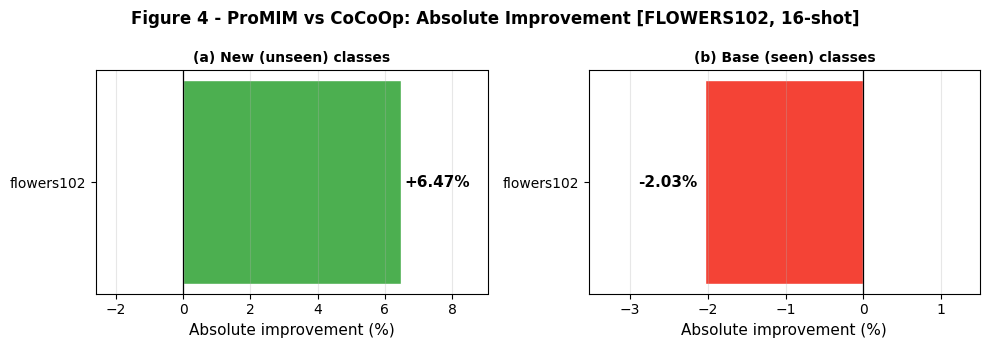

Saved → results/figure4_base_new_deltas.png

Figure 4  [FLOWERS102, 16-shot]
  New  class improvement : +6.47%
  Base class delta       : -2.03%


In [26]:
import matplotlib.pyplot as plt
import numpy as np, os

SHOT_FIG4 = '16'
ds = DATASET_NAME

try:
    c = all_results[ds][SHOT_FIG4]['CoCoOp']
    p = all_results[ds][SHOT_FIG4]['ProMIM_full']
except KeyError:
    raise AssertionError(f"No paired CoCoOp/ProMIM_full results for '{ds}' - run Section 9 first.")

d_new  = round(p['new']  - c['new'],  2)
d_base = round(p['base'] - c['base'], 2)

def _bar_color(v):
    return '#4CAF50' if v >= 0 else '#F44336'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle(f"Figure 4 - ProMIM vs CoCoOp: Absolute Improvement [{ds.upper()}, 16-shot]",
             fontsize=12, fontweight='bold')

for ax, val, title in [
    (ax1, d_new,  "(a) New (unseen) classes"),
    (ax2, d_base, "(b) Base (seen) classes"),
]:
    bar = ax.barh([ds], [val], color=_bar_color(val), edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.9)
    ax.text(val + (0.1 if val >= 0 else -0.1), 0, f"{val:+.2f}%",
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=11, fontweight='bold')
    ax.set_xlabel("Absolute improvement (%)", fontsize=11)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    margin = max(abs(val) * 0.4, 1.5)
    ax.set_xlim(min(val, 0) - margin, max(val, 0) + margin)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/figure4_base_new_deltas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figure4_base_new_deltas.png")
print(f"\nFigure 4  [{ds.upper()}, 16-shot]")
print(f"  New  class improvement : {d_new:+.2f}%")
print(f"  Base class delta       : {d_base:+.2f}%")


## 11. Method Comparison Chart

Four complementary views:
- **(a)** Line chart - accuracy vs. number of shots per method
- **(b)** Grouped bar chart - side-by-side at each shot count
- **(c)** Training-loss curves (16-shot highlighted)
- **(d)** Summary table with delta (ProMIM - CoCoOp) highlighted green/red


In [27]:
import pandas as pd
import json
import os

# =======================================================================
# Section 15 Chart Data Preparation
# Loads the Harmonic Mean (H) from base_new_results.json for the plot.
# =======================================================================

RESULTS_FILE = "base_new_results.json"
if not os.path.exists(RESULTS_FILE):
    raise FileNotFoundError(f"Missing {RESULTS_FILE}. Run Section 9 (Base-to-New) first.")

with open(RESULTS_FILE, "r") as f:
    all_results = json.load(f)

ds_name = DATASET_NAME
if ds_name not in all_results:
    raise ValueError(f"Dataset {ds_name} not found in {RESULTS_FILE}. Run Section 9.")

records = []
for n_shots in SHOT_VALUES:
    shot_key = str(n_shots)
    if shot_key not in all_results[ds_name]:
        continue
    
    data = all_results[ds_name][shot_key]
    
    # 1. CLIP Zero-Shot (constant across shots, but we append it for the chart structure)
    records.append({
        "shots": n_shots,
        "method": "CLIP (zero-shot)",
        "val_acc": data.get("CLIP", {}).get("H", 0.0)
    })
    
    # 2. CoCoOp
    records.append({
        "shots": n_shots,
        "method": "CoCoOp",
        "val_acc": data.get("CoCoOp", {}).get("H", 0.0)
    })

    # 3. ProMIM (MIM only)
    records.append({
        "shots": n_shots,
        "method": "ProMIM_MIM_only",
        "val_acc": data.get("ProMIM_MIM_only", {}).get("H", 0.0)
    })

    # 4. ProMIM (Full)
    records.append({
        "shots": n_shots,
        "method": "ProMIM_full",
        "val_acc": data.get("ProMIM_full", {}).get("H", 0.0)
    })

results_df = pd.DataFrame(records)
print("Successfully loaded Harmonic Mean (H) metrics for plotting:\n")
print(results_df.to_string(index=False))


Successfully loaded Harmonic Mean (H) metrics for plotting:

 shots           method  val_acc
     1 CLIP (zero-shot)  76.1049
     1           CoCoOp  76.9110
     1  ProMIM_MIM_only  76.8796
     1      ProMIM_full  78.8199
     4 CLIP (zero-shot)  76.1049
     4           CoCoOp  78.8682
     4  ProMIM_MIM_only  78.2239
     4      ProMIM_full  80.0956
     8 CLIP (zero-shot)  76.1049
     8           CoCoOp  76.9394
     8  ProMIM_MIM_only  76.8676
     8      ProMIM_full  79.2613
    16 CLIP (zero-shot)  76.1049
    16           CoCoOp  78.1682
    16  ProMIM_MIM_only  37.4361
    16      ProMIM_full  81.7051


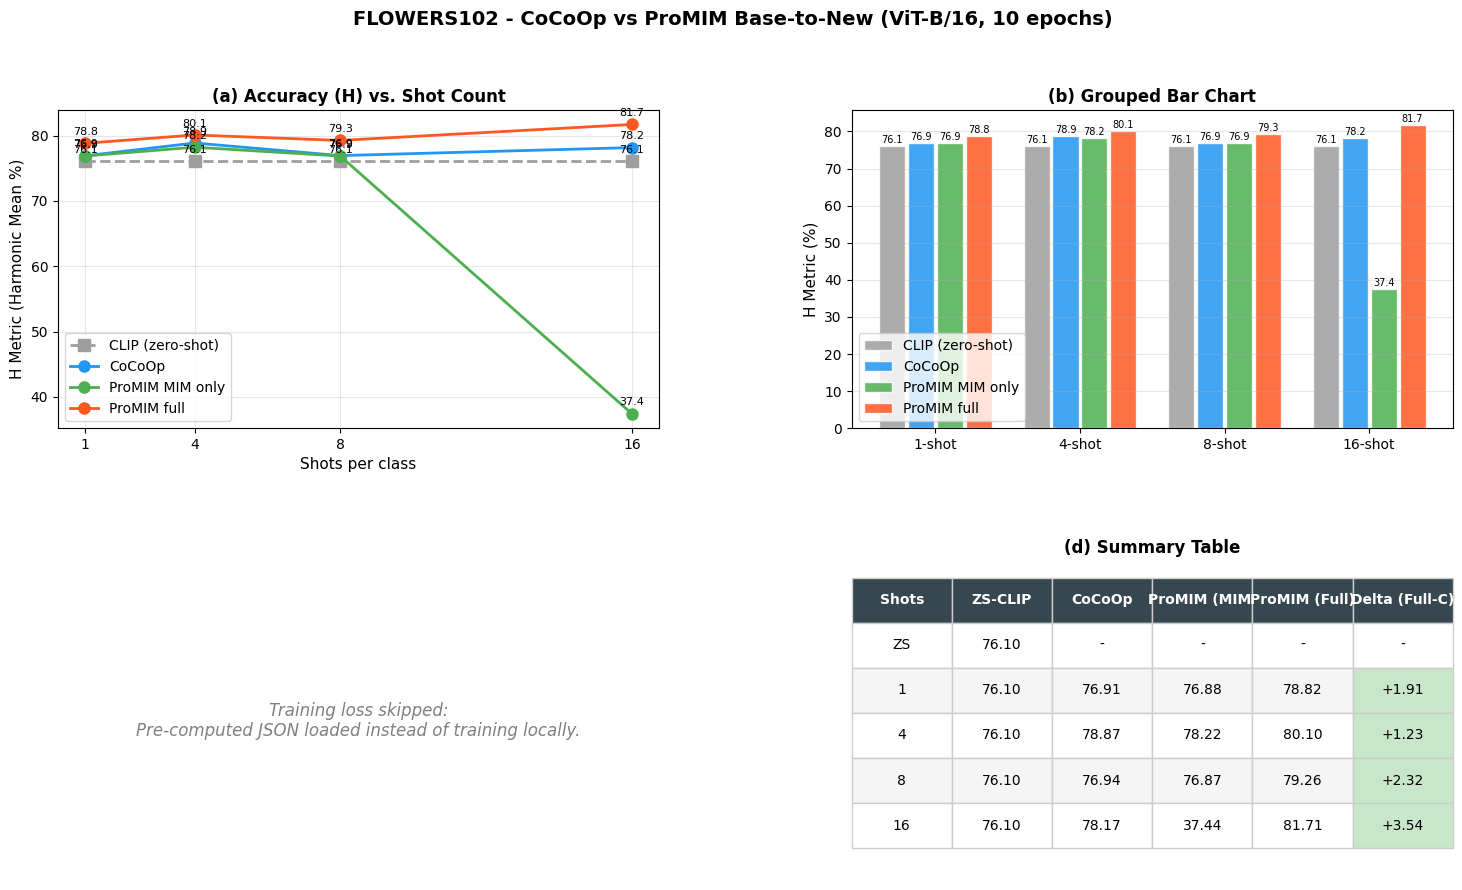

Saved: results\method_comparison_chart.png
Saved CSV: results\summary_table.csv


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import csv

clip_zs_acc = results_df[results_df["method"] == "CLIP (zero-shot)"]["val_acc"].iloc[0]

COLORS = {
    "CLIP (zero-shot)": "#9E9E9E",
    "CoCoOp":           "#2196F3",
    "ProMIM_MIM_only":  "#4CAF50",
    "ProMIM_full":      "#FF5722",
}
METHODS_ORDERED = ["CLIP (zero-shot)", "CoCoOp", "ProMIM_MIM_only", "ProMIM_full"]

# Ensure dataset directory exists for saving results
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f"{DATASET_NAME.upper()} - CoCoOp vs ProMIM Base-to-New (ViT-B/16, {N_EPOCHS} epochs)",
    fontsize=14, fontweight="bold", y=0.98)

gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)

# (a) Line chart: accuracy vs shots 
ax1 = fig.add_subplot(gs[0, 0])
for method in METHODS_ORDERED:
    sub = results_df[results_df["method"] == method]
    ls  = "--" if method == "CLIP (zero-shot)" else "-"
    mk  = "s" if method == "CLIP (zero-shot)" else "o"
    ax1.plot(sub["shots"].astype(int), sub["val_acc"],
             marker=mk, linestyle=ls, linewidth=2, markersize=8,
             color=COLORS[method], label=method.replace("_", " "))
    for _, row in sub.iterrows():
        ax1.annotate(f"{row.val_acc:.1f}",
                     (row.shots, row.val_acc),
                     textcoords="offset points", xytext=(0, 6),
                     ha="center", fontsize=8)
ax1.set_xlabel("Shots per class", fontsize=11)
ax1.set_ylabel("H Metric (Harmonic Mean %)", fontsize=11)
ax1.set_title("(a) Accuracy (H) vs. Shot Count", fontsize=12, fontweight="bold")
ax1.set_xticks(SHOT_VALUES)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# (b) Grouped bar chart 
ax2 = fig.add_subplot(gs[0, 1])
x        = np.arange(len(SHOT_VALUES))
bar_w    = 0.20
offsets  = [-bar_w*1.5, -bar_w*0.5, bar_w*0.5, bar_w*1.5]
for j, method in enumerate(METHODS_ORDERED):
    vals = []
    for s in SHOT_VALUES:
        row = results_df[(results_df["method"] == method) &
                         (results_df["shots"] == s)]
        vals.append(float(row["val_acc"].values[0]))
    bars = ax2.bar(x + offsets[j], vals, bar_w - 0.02,
                   color=COLORS[method], alpha=0.85,
                   label=method.replace("_", " "), edgecolor="white")
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{v:.1f}", ha="center", va="bottom", fontsize=7)
ax2.set_xticks(x)
ax2.set_xticklabels([f"{s}-shot" for s in SHOT_VALUES])
ax2.set_ylabel("H Metric (%)", fontsize=11)
ax2.set_title("(b) Grouped Bar Chart", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

# (c) Training-loss curves - we disable this since we dont log losses anymore! 
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis("off")
ax3.text(0.5, 0.5, "Training loss skipped:\nPre-computed JSON loaded instead of training locally.", 
         ha="center", va="center", fontsize=12, color="gray", fontstyle="italic")

# (d) Summary table 
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")

col_labels = ["Shots", "ZS-CLIP", "CoCoOp", "ProMIM (MIM)", "ProMIM (Full)", "Delta (Full-C)"]
rows_data  = []
rows_data.append(["ZS", f"{clip_zs_acc:.2f}", "-", "-", "-", "-"])

pivot = results_df[results_df["method"] != "CLIP (zero-shot)"].pivot(
    index="shots", columns="method", values="val_acc")
for shot in SHOT_VALUES:
    c   = pivot.loc[shot, "CoCoOp"]
    mo  = pivot.loc[shot, "ProMIM_MIM_only"]
    mf  = pivot.loc[shot, "ProMIM_full"]
    d   = mf - c
    sgn = "+" if d >= 0 else ""
    rows_data.append([str(shot), f"{clip_zs_acc:.2f}",
                      f"{c:.2f}", f"{mo:.2f}", f"{mf:.2f}", f"{sgn}{d:.2f}"])

tbl = ax4.table(cellText=rows_data, colLabels=col_labels,
                cellLoc="center", loc="center",
                bbox=[0.0, 0.1, 1.0, 0.85])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if row == 0:
        cell.set_facecolor("#37474F")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 5 and row > 0:
        val_str = rows_data[row - 1][5]
        if val_str not in ("-", ""):
            cell.set_facecolor("#C8E6C9" if float(val_str) >= 0 else "#FFCDD2")
    elif row % 2 == 0:
        cell.set_facecolor("#F5F5F5")
ax4.set_title("(d) Summary Table", fontsize=12, fontweight="bold")
save_path = os.path.join(results_dir, "method_comparison_chart.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

csv_path = os.path.join(results_dir, "summary_table.csv")
with open(csv_path, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(col_labels)   # header
    writer.writerows(rows_data)   # data
print(f"Saved CSV: {csv_path}")


## 12. Text-to-Image Attention Map Visualisation

Occlusion-sensitivity maps: a grey patch slides over the image and we  
record how much cosine similarity to the predicted class drops.  
High-drop regions are most important for the model's prediction.

The same image is shown under:
1. CLIP zero-shot (uses `get_template` for dataset)
2. CoCoOp learned text features (16-shot, re-train if needed)
3. ProMIM learned text features (16-shot, re-train if needed)


Loading 16-shot CoCoOp & ProMIM from saved checkpoints ...
  CoCoOp loaded from ckpts\flowers102__CoCoOp__16shot.pt
  ProMIM loaded from ckpts\flowers102__ProMIM_full__16shot.pt
Text features extracted for all 3 methods (ZS / CoCoOp / ProMIM).


  Sample image 1  (val index 0)

  True label   : passion flower
  CLIP ZS pred : passion flower
  CoCoOp  pred : clematis
  ProMIM  pred : passion flower
  Generating occlusion maps (3 methods) ...


C:\Users\lambr\AppData\Local\Temp\ipykernel_20020\2937187688.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


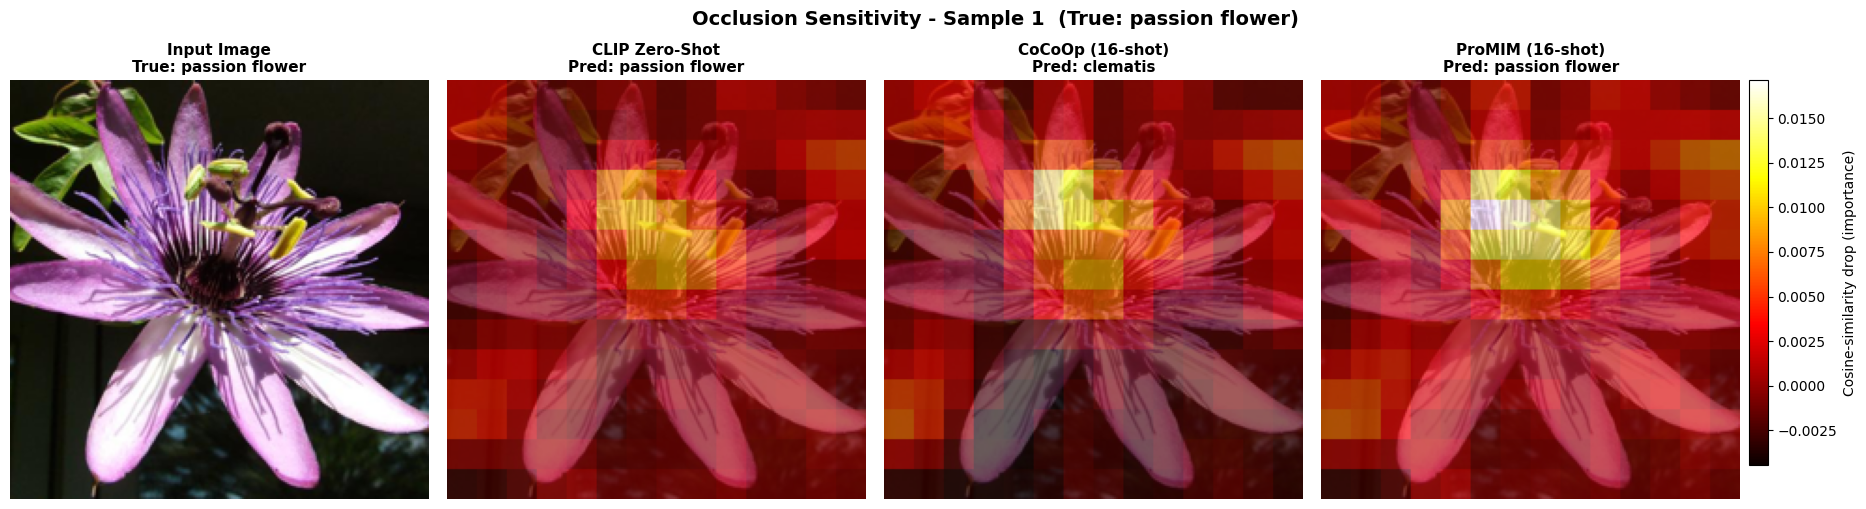

  Saved: attention_map_sample1.png


  Sample image 2  (val index 12)

  True label   : passion flower
  CLIP ZS pred : passion flower
  CoCoOp  pred : passion flower
  ProMIM  pred : passion flower
  Generating occlusion maps (3 methods) ...


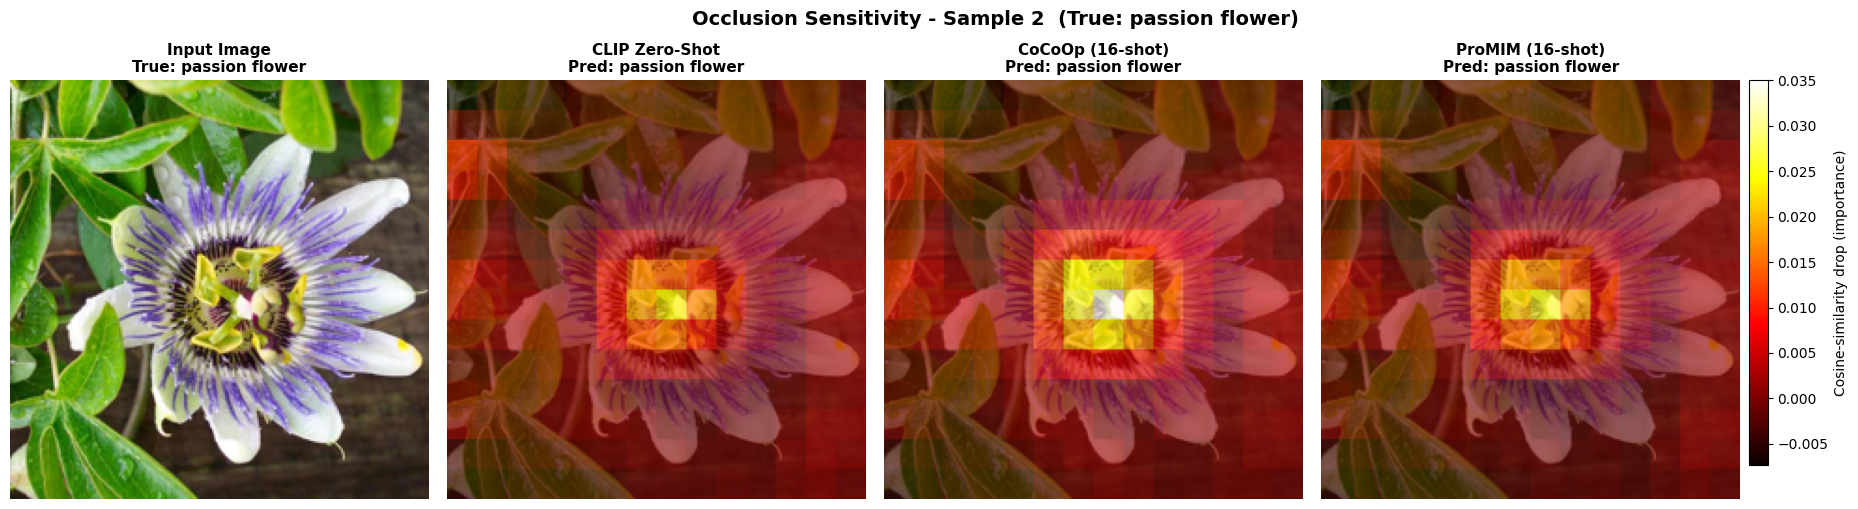

  Saved: attention_map_sample2.png

Attention map comparison complete for both samples.


In [29]:
@torch.no_grad()
def get_text_features_zeroshot(classnames, clip_model, device):
    """Standard CLIP zero-shot text features (one prompt per class)."""
    feats = []
    _template = get_template(DATASET_NAME)
    for c in classnames:
        tok  = clip.tokenize(_template.format(c)).to(device)
        feat = clip_model.encode_text(tok)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        feats.append(feat[0])
    return torch.stack(feats)   # (n_cls, D)


@torch.no_grad()
def get_text_features_from_model(model, device):
    """Extract text features from a trained CoCoOp or ProMIM model.
    Uses several validation images to condition the meta-net, then
    averages the resulting text features for stability (the meta-net
    shift depends on the input image).
    """
    model.eval()
    tokenized = model.tokenized_prompts
    n_avg = min(8, len(val_dataset))
    all_tf = []
    for i in range(n_avg):
        img_i, _ = val_dataset[i]
        img_i = img_i.unsqueeze(0).to(device)
        img_feat = model.image_encoder(img_i.type(model.dtype))
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        prompts = model.prompt_learner(img_feat)   # (1, n_cls, L, D)
        tf = model.text_encoder(prompts[0], tokenized)
        tf = tf / tf.norm(dim=-1, keepdim=True)
        all_tf.append(tf)
    avg_tf = torch.stack(all_tf).mean(0)           # (n_cls, D)
    avg_tf = avg_tf / avg_tf.norm(dim=-1, keepdim=True)
    return avg_tf


def generate_occlusion_map(img_tensor, text_feats, cls_idx,
                            patch_size=32, stride=16, device="cuda"):
    """
    Slide a grey patch over img_tensor; record cosine similarity drop
    to text_feats[cls_idx].

    img_tensor : (1, 3, 224, 224)  pre-processed image tensor
    Returns    : numpy heatmap  (224, 224)
    """
    _, _, H, W = img_tensor.shape
    heatmap    = torch.zeros(H, W, device=device)
    counts     = torch.zeros(H, W, device=device)

    with torch.no_grad():
        base_feat = clip_model.encode_image(img_tensor.to(device))
        base_feat = base_feat / base_feat.norm(dim=-1, keepdim=True)
        base_sim  = (base_feat @ text_feats[cls_idx]).item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occ = img_tensor.clone().to(device)
            occ[:, :, y:y + patch_size, x:x + patch_size] = 0.5  # grey patch
            with torch.no_grad():
                feat = clip_model.encode_image(occ)
                feat = feat / feat.norm(dim=-1, keepdim=True)
                drop = base_sim - (feat @ text_feats[cls_idx]).item()
            heatmap[y:y + patch_size, x:x + patch_size] += drop
            counts [y:y + patch_size, x:x + patch_size] += 1

    return (heatmap / counts.clamp(min=1)).cpu().numpy()


def unnormalize(t):
    """Reverse CLIP preprocessing for display."""
    mean = torch.tensor([0.48145466, 0.4578275,  0.40821073])
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711])
    t    = t * std[:, None, None] + mean[:, None, None]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


# Load saved 16-shot models from Section 9 checkpoints
# Paths match exactly what Cell 21 saves via _ckpt_path()
os.makedirs("results", exist_ok=True)
results_dir = "results"

print("Loading 16-shot CoCoOp & ProMIM from saved checkpoints ...")
_n_shots_attn = 16

cocoop = CoCoOpModel(CLASSES, clip_model, n_ctx=N_CTX, ctx_init="a photo of a").to(device)
cocoop_path = _ckpt_path(DATASET_NAME, "CoCoOp", _n_shots_attn)
assert os.path.exists(cocoop_path), (
    f"Checkpoint not found: {cocoop_path}\n"
    f"Run Section 9 first to train and save the 16-shot CoCoOp model.")
cocoop.prompt_learner.load_state_dict(torch.load(cocoop_path, map_location=device))
cocoop.eval()
print(f"  CoCoOp loaded from {cocoop_path}")

promim = ProMIMModel(CLASSES, clip_model, n_ctx=N_CTX, ctx_init="a photo of a",
                     mask_ratio=MASK_RATIO, lambda_kg=LAMBDA_KG).to(device)
promim_path = _ckpt_path(DATASET_NAME, "ProMIM_full", _n_shots_attn)
assert os.path.exists(promim_path), (
    f"Checkpoint not found: {promim_path}\n"
    f"Run Section 9 first to train and save the 16-shot ProMIM model.")
promim.prompt_learner.load_state_dict(torch.load(promim_path, map_location=device))
promim.eval()
print(f"  ProMIM loaded from {promim_path}")

# Extract text features for each method
zs_feats     = get_text_features_zeroshot(CLASSES, clip_model, device)
cocoop_feats = get_text_features_from_model(cocoop, device)
promim_feats = get_text_features_from_model(promim, device)
print("Text features extracted for all 3 methods (ZS / CoCoOp / ProMIM).")

# Free loaded models - only text features are needed from here
del cocoop, promim
torch.cuda.empty_cache()

# Generate occlusion maps for 2 sample images 
SAMPLE_INDICES = [0, 12]   # two different validation images

for img_num, SAMPLE_IDX in enumerate(SAMPLE_INDICES, start=1):
    print(f"\n{''*60}")
    print(f"  Sample image {img_num}  (val index {SAMPLE_IDX})")
    print(f"{''*60}")

    sample_img, sample_label = val_dataset[SAMPLE_IDX]
    sample_tensor = sample_img.unsqueeze(0)
    img_np        = unnormalize(sample_img)

    # Predict class with each method's text features
    with torch.no_grad():
        img_f = clip_model.encode_image(sample_tensor.to(device))
        img_f = img_f / img_f.norm(dim=-1, keepdim=True)
        pred_zs = (img_f @ zs_feats.T).argmax().item()
        pred_cc = (img_f @ cocoop_feats.T).argmax().item()
        pred_pm = (img_f @ promim_feats.T).argmax().item()

    print(f"  True label   : {CLASSES[sample_label]}")
    print(f"  CLIP ZS pred : {CLASSES[pred_zs]}")
    print(f"  CoCoOp  pred : {CLASSES[pred_cc]}")
    print(f"  ProMIM  pred : {CLASSES[pred_pm]}")

    # Generate occlusion maps (one per method)
    print("  Generating occlusion maps (3 methods) ...")
    hmap_zs = generate_occlusion_map(sample_tensor, zs_feats,     pred_zs, device=device)
    hmap_cc = generate_occlusion_map(sample_tensor, cocoop_feats, pred_cc, device=device)
    hmap_pm = generate_occlusion_map(sample_tensor, promim_feats, pred_pm, device=device)

    # Shared colour scale across all three heatmaps
    vmin = min(hmap_zs.min(), hmap_cc.min(), hmap_pm.min())
    vmax = max(hmap_zs.max(), hmap_cc.max(), hmap_pm.max())

    # Plot 1×4 figure 
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f"Occlusion Sensitivity - Sample {img_num}  "
        f"(True: {CLASSES[sample_label]})",
        fontsize=14, fontweight="bold", y=1.02)

    # (a) Original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"Input Image\nTrue: {CLASSES[sample_label]}",
                      fontsize=11, fontweight="bold")
    axes[0].axis("off")

    # (b) CLIP Zero-Shot
    axes[1].imshow(img_np)
    axes[1].imshow(hmap_zs, alpha=0.65, cmap="hot", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"CLIP Zero-Shot\nPred: {CLASSES[pred_zs]}",
                      fontsize=11, fontweight="bold")
    axes[1].axis("off")

    # (c) CoCoOp (16-shot)
    axes[2].imshow(img_np)
    axes[2].imshow(hmap_cc, alpha=0.65, cmap="hot", vmin=vmin, vmax=vmax)
    axes[2].set_title(f"CoCoOp (16-shot)\nPred: {CLASSES[pred_cc]}",
                      fontsize=11, fontweight="bold")
    axes[2].axis("off")

    # (d) ProMIM (16-shot)
    axes[3].imshow(img_np)
    axes[3].imshow(hmap_pm, alpha=0.65, cmap="hot", vmin=vmin, vmax=vmax)
    axes[3].set_title(f"ProMIM (16-shot)\nPred: {CLASSES[pred_pm]}",
                      fontsize=11, fontweight="bold")
    axes[3].axis("off")

    # Shared colour bar
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    sm = ScalarMappable(cmap="hot", norm=Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.03, pad=0.02)
    cbar.set_label("Cosine-similarity drop (importance)", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    fname = f"attention_map_sample{img_num}.png"
    save_path = os.path.join(results_dir, fname)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

print("\nAttention map comparison complete for both samples.")


## 13. Hyperparameter Ablation at 16-shot

- **Table 7** - mask ratio in {0.25, 0.50, 0.75, 0.95}
- **Table 8** - lambda in {0.0, 1.0, 2.0, 4.0}


In [30]:
# # Safe fallback in case Section 16 was skipped
# os.makedirs("results", exist_ok=True)
# results_dir = "results"

# # Ensure dataset directory exists for saving models
# ablation_models_dir = "ablation_models"
# os.makedirs(ablation_models_dir, exist_ok=True)

# ABLATION_SHOT = 16
# # IMPORTANT: Ablation must be trained strictly on BASE classes to evaluate Base-to-New Generalization Harmonic Mean!
# base_train_ds = filter_dataset_by_classes(train_dataset, base_ids)
# few_shot_abl  = sample_few_shot(base_train_ds, n_shots=ABLATION_SHOT, seed=SEED)

# # Mask ratio ablation 
# mask_ratios = [0.25, 0.50, 0.75, 0.95]
# mask_accs   = []
# print(f"Mask ratio ablation ({ABLATION_SHOT}-shot) ...")

# for mr in mask_ratios:
#     promim_mask_ablations_path = os.path.join(ablation_models_dir, f"{DATASET_NAME}_promim_mask{mr}_{ABLATION_SHOT}shot.pt")

#     m = ProMIMModel(CLASSES, clip_model, n_ctx=N_CTX, ctx_init="a photo of a",
#                     mask_ratio=mr, lambda_kg=LAMBDA_KG, template=template).to(device)

#     if os.path.exists(promim_mask_ablations_path):
#         print(f"  Loading model from {promim_mask_ablations_path} ...")
#         m.prompt_learner.load_state_dict(torch.load(promim_mask_ablations_path, map_location=device))
#     else:
#         print(f"  Training model (mask_ratio={mr}) ...")
#         train_model(m, few_shot_abl, n_epochs=N_EPOCHS, lr=LR_PROMIM,
#                     batch_size=1, model_name=f"ProMIM mr={mr}")
#         torch.save(m.prompt_learner.state_dict(), promim_mask_ablations_path)
#         print(f"  Saved: {promim_mask_ablations_path}")

#     b, n, H = _eval_base_new(m, base_test_loader, new_test_loader, DATASET_NAME, CLASSES, base_ids, new_ids)
#     mask_accs.append(H)
#     print(f"  mask_ratio={mr:.2f}  ->  Base={b:.2f}  New={n:.2f}  H={H:.2f}")

#     del m
#     if device == "cuda": torch.cuda.empty_cache()

# # Lambda ablation 
# lambdas     = [0.0, 1.0, 2.0, 4.0]
# lambda_accs = []
# print(f"\nLambda ablation ({ABLATION_SHOT}-shot) ...")

# for lam in lambdas:
#     promim_lambda_ablations_path = os.path.join(ablation_models_dir, f"{DATASET_NAME}_promim_lambda{lam}_{ABLATION_SHOT}shot.pt")

#     m = ProMIMModel(CLASSES, clip_model, n_ctx=N_CTX, ctx_init="a photo of a",
#                     mask_ratio=MASK_RATIO, lambda_kg=lam, template=template).to(device)

#     if os.path.exists(promim_lambda_ablations_path):
#         print(f"  Loading model from {promim_lambda_ablations_path} ...")
#         m.prompt_learner.load_state_dict(torch.load(promim_lambda_ablations_path, map_location=device))
#     else:
#         print(f"  Training model (lambda={lam}) ...")
#         train_model(m, few_shot_abl, n_epochs=N_EPOCHS, lr=LR_PROMIM,
#                     batch_size=1, model_name=f"ProMIM lam={lam}", lambda_kg=lam)
#         torch.save(m.prompt_learner.state_dict(), promim_lambda_ablations_path)
#         print(f"  Saved: {promim_lambda_ablations_path}")

#     b, n, H = _eval_base_new(m, base_test_loader, new_test_loader, DATASET_NAME, CLASSES, base_ids, new_ids)
#     lambda_accs.append(H)
#     print(f"  lambda={lam}  ->  Base={b:.2f}  New={n:.2f}  H={H:.2f}")

#     del m
#     if device == "cuda": torch.cuda.empty_cache()

# # Plot 
# import matplotlib.pyplot as plt
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# ax1.plot(mask_ratios, mask_accs, "o-", color="#FF5722", lw=2, ms=8)
# ax1.axvline(x=0.75, color="grey", ls="--", alpha=0.6, label="Paper best (0.75)")
# for xv, yv in zip(mask_ratios, mask_accs):
#     ax1.annotate(f"{yv:.1f}", (xv, yv),
#                  textcoords="offset points", xytext=(0, 8),
#                  ha="center", fontsize=9)
# ax1.set_xlabel("Mask ratio")
# ax1.set_ylabel("H Metric (Harmonic Mean %)")
# ax1.set_title(f"Mask Ratio Ablation ({ABLATION_SHOT}-shot)", fontweight="bold")
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# ax2.plot(lambdas, lambda_accs, "s-", color="#9C27B0", lw=2, ms=8)
# ax2.axvline(x=2.0, color="grey", ls="--", alpha=0.6, label="Paper best (lambda=2)")
# for xv, yv in zip(lambdas, lambda_accs):
#     ax2.annotate(f"{yv:.1f}", (xv, yv),
#                  textcoords="offset points", xytext=(0, 8),
#                  ha="center", fontsize=9)
# ax2.set_xlabel("lambda (KgCoOp weight)")
# ax2.set_ylabel("H Metric (Harmonic Mean %)")
# ax2.set_title(f"Lambda Ablation ({ABLATION_SHOT}-shot)", fontweight="bold")
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# save_path = os.path.join(results_dir, f"{DATASET_NAME}_ablation_results.png")
# plt.savefig(save_path, dpi=150, bbox_inches="tight")
# plt.show()
# print(f"Saved: {save_path}")


## 14. Embedding Space Visualisation - PCA, t-SNE, UMAP

Extracts CLIP image features from the validation set and project them  
to 2-D using three dimensionality-reduction methods:

| Method | Strengths | Weaknesses |
|---|---|---|
| **PCA** | Fast, linear, deterministic | May miss non-linear structure |
| **t-SNE** | Preserves local neighbourhoods | Slow, stochastic, crowding |
| **UMAP** | Preserves local & global structure | Sensitive to `n_neighbors` |

The same features feed all three methods for a direct comparison.  
Colour = ground-truth class label (first 15 classes shown for clarity).  
A second subplot shows **text** features (zero-shot prompts) for all classes.


Extracting CLIP image features (up to 500 val images) ...
  Feature matrix: (500, 512)   Labels: (500,)
  Total classes in sample: 101,  samples: 500
Running PCA on image features ...
Running t-SNE on image features (may take ~30 s) ...
Running UMAP on image features ...


C:\Users\lambr\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


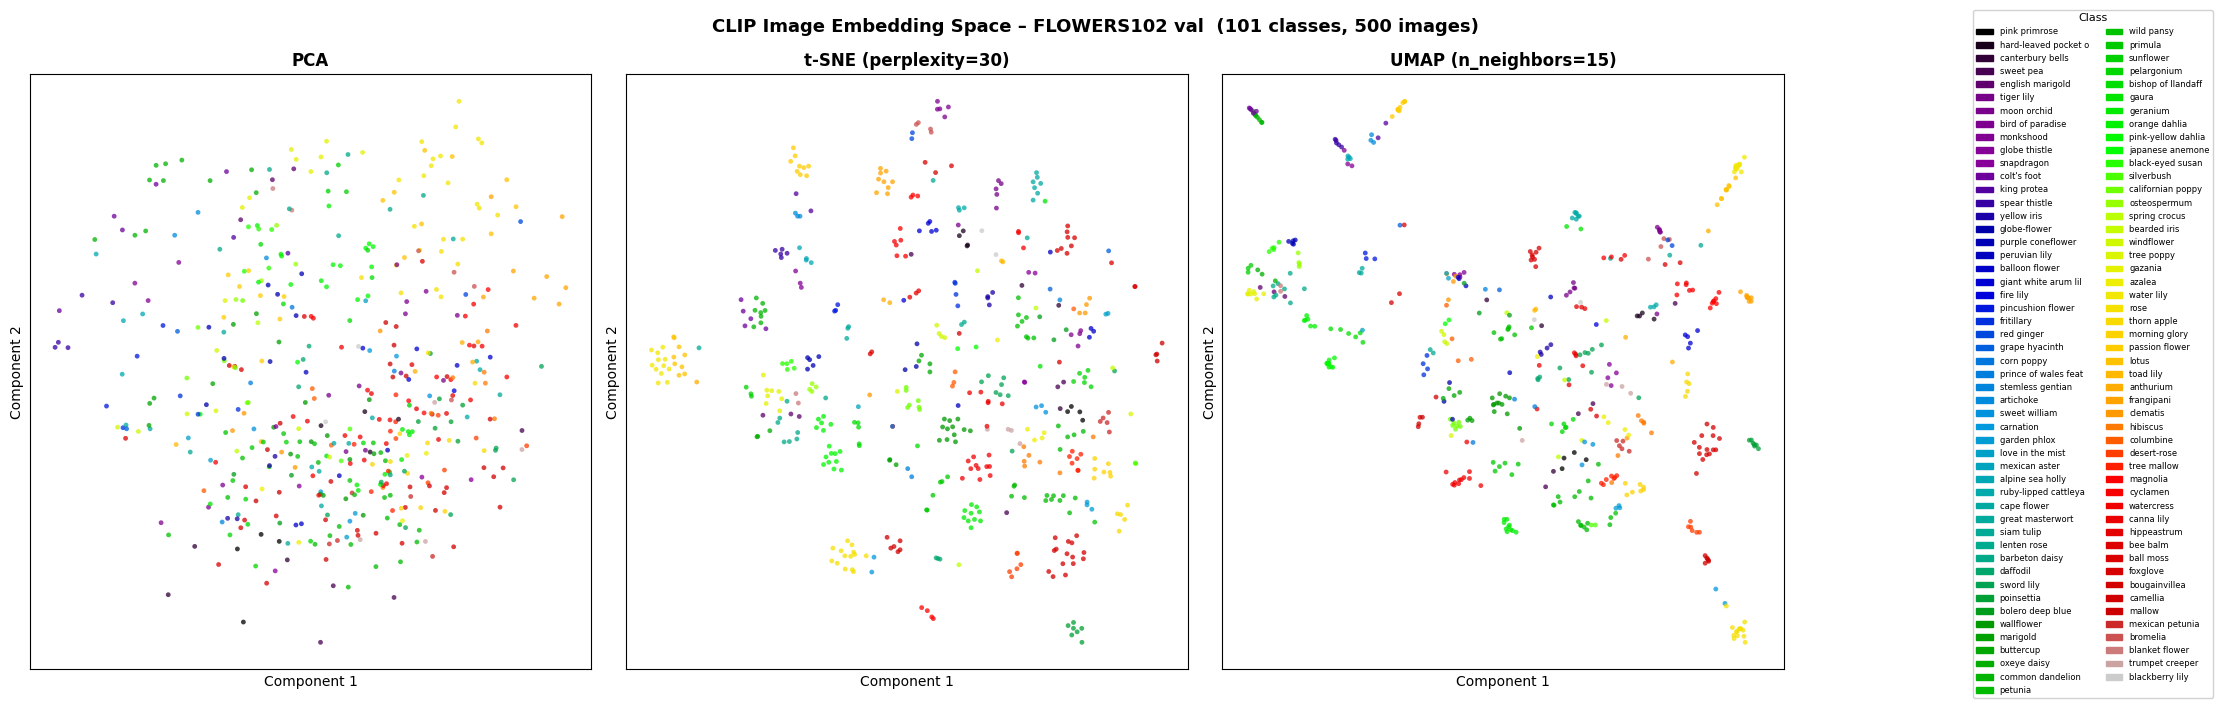

Saved: results\image_embedding_visualisation.png

Extracting CLIP zero-shot text features ...
Extracting CoCoOp text features ...
  Loaded: ckpts\flowers102__CoCoOp__16shot.pt
Extracting ProMIM text features ...
  Loaded: ckpts\flowers102__ProMIM_full__16shot.pt

Running shared PCA on combined text features ...
Running shared t-SNE on combined text features ...
Running shared UMAP on combined text features ...


C:\Users\lambr\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


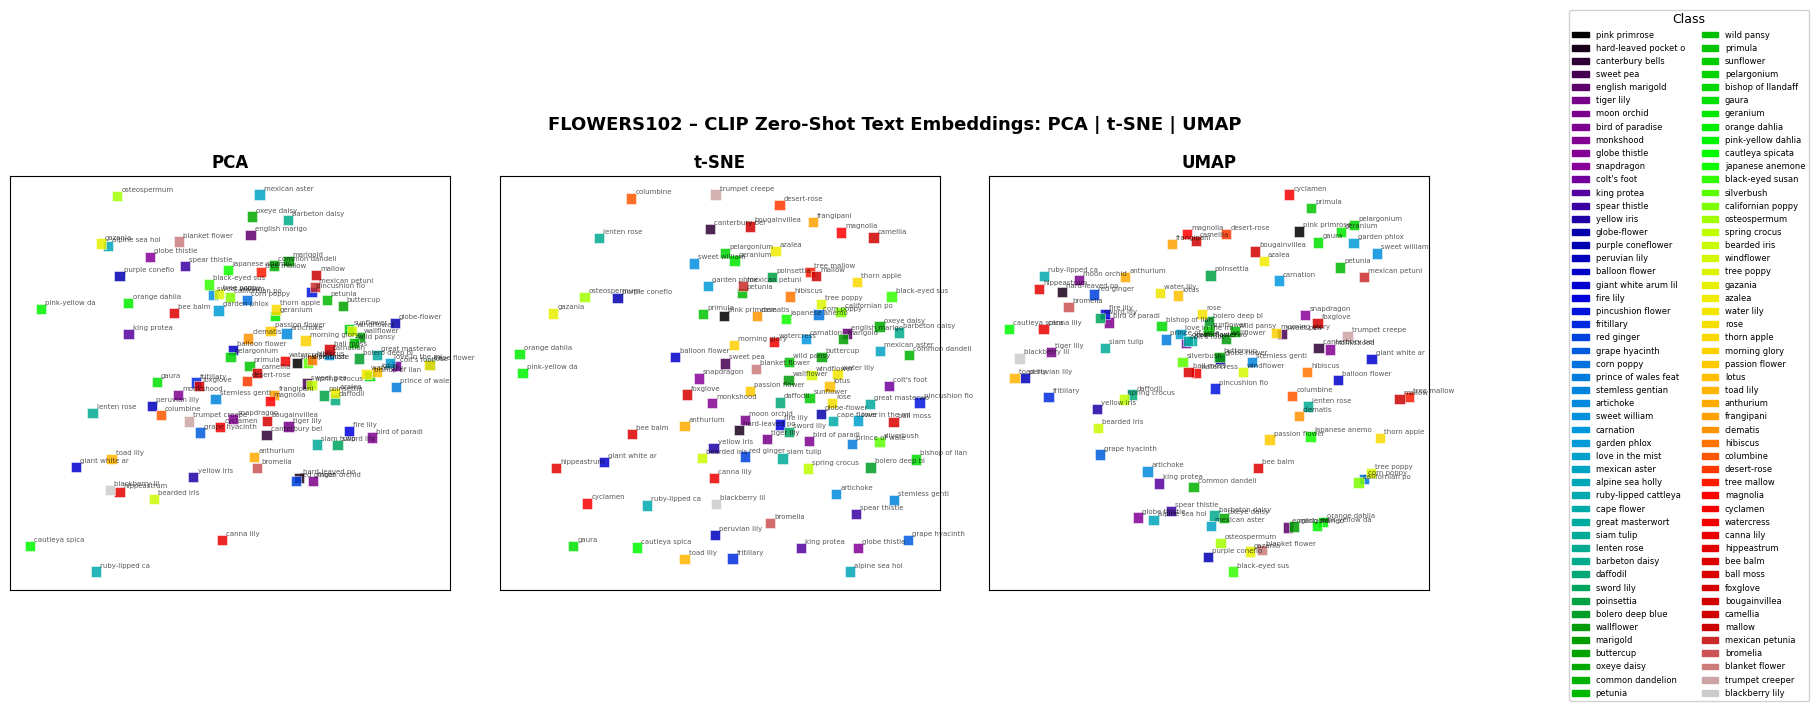

Saved: results\flowers102_clip_zs_pca_tsne_umap.png


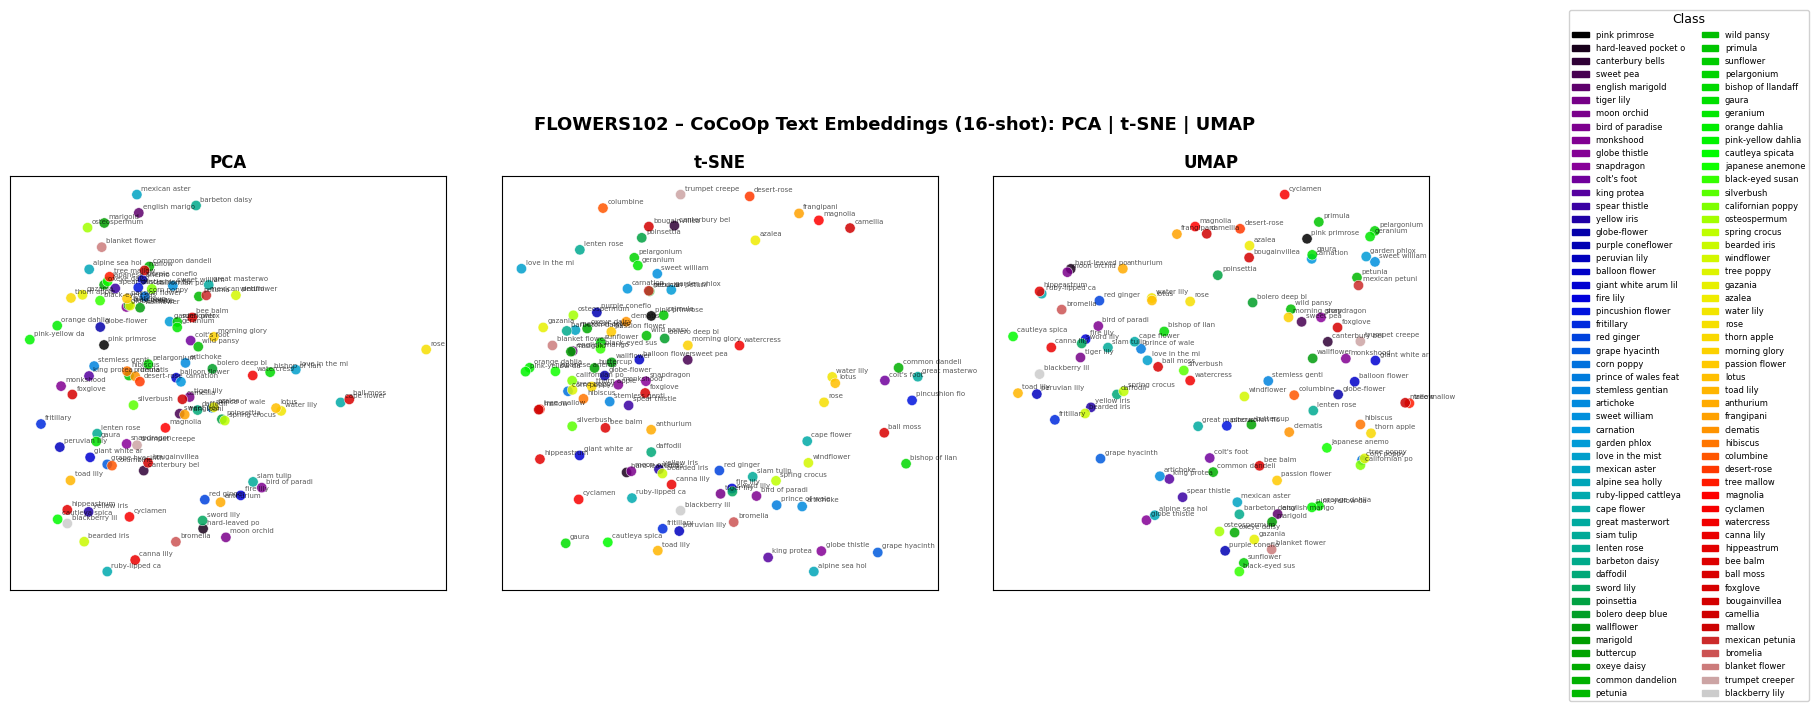

Saved: results\flowers102_cocoop_pca_tsne_umap.png


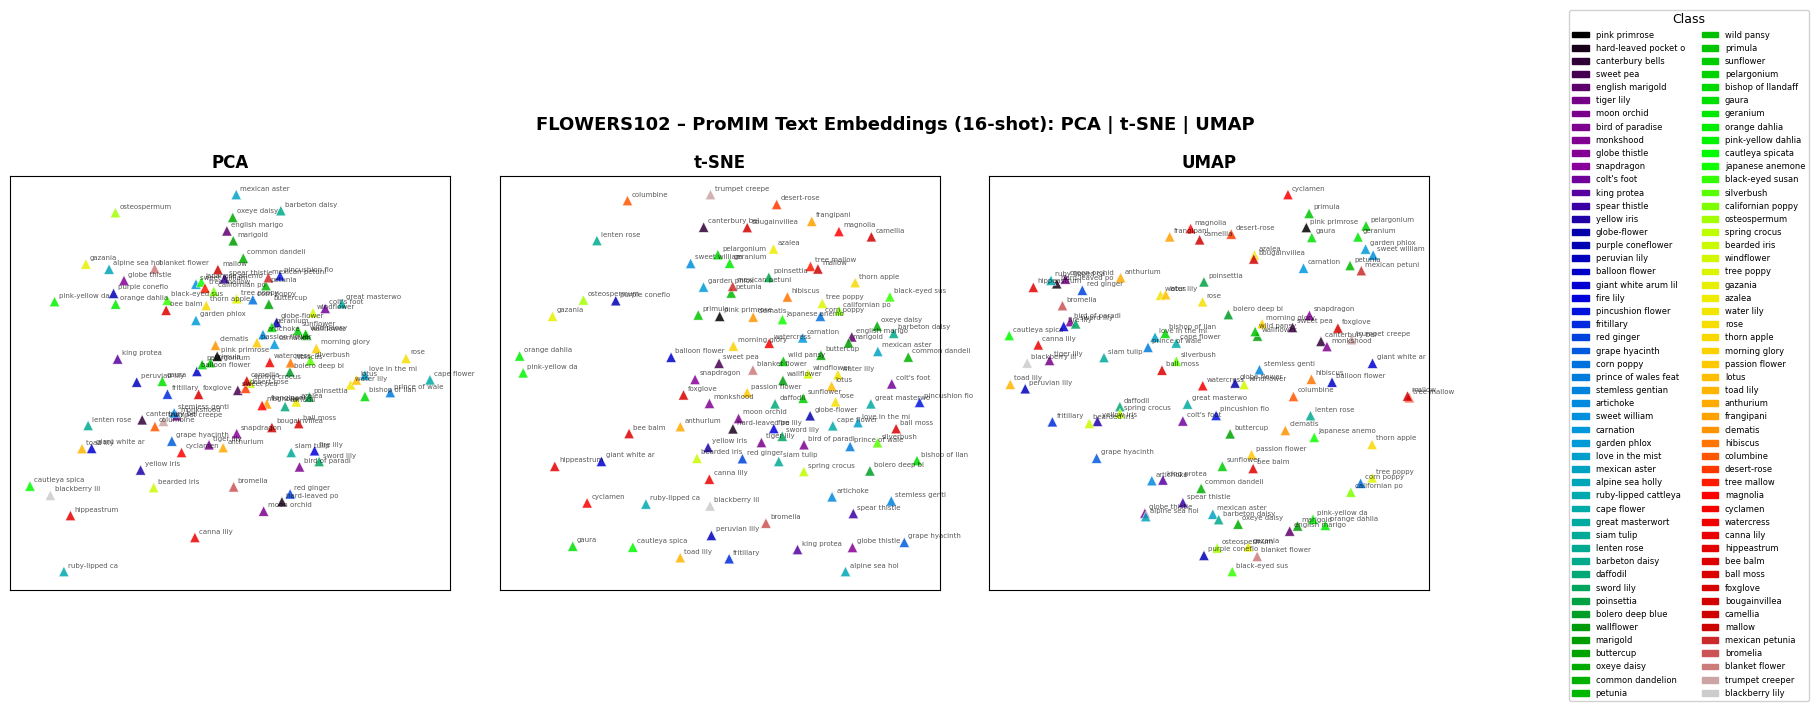

Saved: results\flowers102_promim_pca_tsne_umap.png

Computing cosine similarity drift from CLIP ZS ...


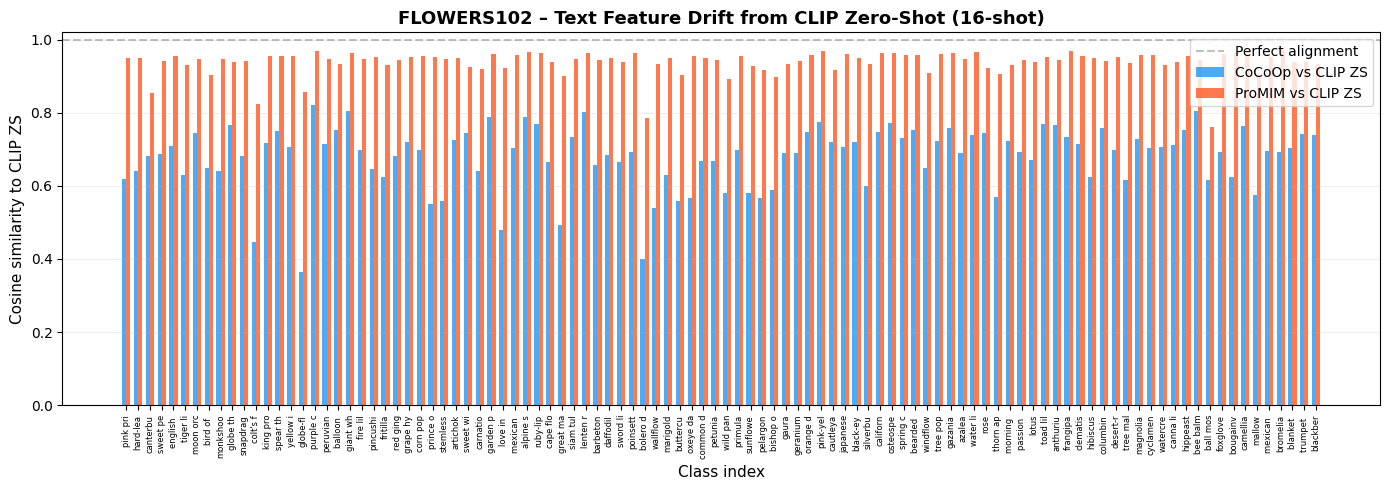

Saved: results\flowers102_text_cosine_drift.png

Mean cosine sim to CLIP ZS:
  CoCoOp : 0.6797
  ProMIM : 0.9380
  (ProMIM should be closer to 1.0 due to L_kg regularisation)

Report Discussion:
- Do semantically related classes cluster together in the image embedding space?
- Does t-SNE show tighter within-class clusters than PCA?
- Do UMAP's global and local structures differ from t-SNE?
- Compare CLIP ZS vs CoCoOp vs ProMIM text embedding geometry – which preserves
  the original CLIP structure most faithfully?
- Does ProMIM show less drift from CLIP ZS than CoCoOp (expect yes, due to L_kg)?



In [31]:
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap as umap_lib

# =====================================================================
# Image feature embeddings (CLIP visual encoder, val set)
# =====================================================================
MAX_VIZ_SAMPLES = 500
print(f"Extracting CLIP image features (up to {MAX_VIZ_SAMPLES} val images) ...")
feats_np, labels_np = collect_image_features(val_dataset, clip_model, device, max_samples=MAX_VIZ_SAMPLES)
print(f"  Feature matrix: {feats_np.shape}   Labels: {labels_np.shape}")

# Use ALL classes present in the sample
unique_ids     = np.sort(np.unique(labels_np))
N_VIZ_CLASSES  = len(unique_ids)
feats_viz      = feats_np
labels_viz     = labels_np

# Remap original (possibly non-contiguous) IDs → 0..N-1 for colouring
label_to_idx   = {cls_id: i for i, cls_id in enumerate(unique_ids)}
labels_viz_idx = np.array([label_to_idx[l] for l in labels_viz])

print(f"  Total classes in sample: {N_VIZ_CLASSES},  samples: {feats_viz.shape[0]}")

# Use a continuous colormap that handles large N well
cmap    = matplotlib.colormaps.get_cmap("nipy_spectral").resampled(N_VIZ_CLASSES)
colors  = [cmap(i) for i in range(N_VIZ_CLASSES)]
patches = [mpatches.Patch(color=colors[i], label=CLASSES[unique_ids[i]][:20])
           for i in range(N_VIZ_CLASSES)]

print("Running PCA on image features ...")
pca_img  = PCA(n_components=2, random_state=42).fit_transform(feats_viz)
print("Running t-SNE on image features (may take ~30 s) ...")
tsne_img = TSNE(n_components=2, perplexity=30, max_iter=1000,
                random_state=42, init="pca").fit_transform(feats_viz)
print("Running UMAP on image features ...")
umap_img = umap_lib.UMAP(n_components=2, n_neighbors=15,
                          min_dist=0.1, random_state=42).fit_transform(feats_viz)

fig1, axes1 = plt.subplots(1, 3, figsize=(22, 7))
fig1.suptitle(
    f"CLIP Image Embedding Space – {DATASET_NAME.upper()} val  "
    f"({N_VIZ_CLASSES} classes, {feats_viz.shape[0]} images)",
    fontsize=13, fontweight="bold")

for ax, emb, title in zip(axes1,
                           [pca_img, tsne_img, umap_img],
                           ["PCA", "t-SNE (perplexity=30)", "UMAP (n_neighbors=15)"]):
    c_vals = [colors[int(l)] for l in labels_viz_idx]
    ax.scatter(emb[:, 0], emb[:, 1], c=c_vals, s=12, alpha=0.75, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")

fig1.legend(handles=patches, loc="center right",
            bbox_to_anchor=(1.01, 0.5), fontsize=6,
            title="Class", title_fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 0.82, 1])
save_path = os.path.join(results_dir, "image_embedding_visualisation.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# =====================================================================
# Extract text features: CLIP ZS, CoCoOp, ProMIM
# =====================================================================
VIZ_SHOTS = 16
template  = get_template(DATASET_NAME)
N_LABEL   = len(CLASSES)

# -- CLIP Zero-Shot --
print("\nExtracting CLIP zero-shot text features ...")
if 'zs_feats' not in dir() or not isinstance(zs_feats, torch.Tensor):
    print("  zs_feats not found – recomputing ...")
    with torch.no_grad():
        _toks = torch.cat([clip.tokenize(template.format(c)) for c in CLASSES]).to(device)
        zs_feats = clip_model.encode_text(_toks)
        zs_feats = zs_feats / zs_feats.norm(dim=-1, keepdim=True)
zs_np = zs_feats.cpu().numpy()   # (n_cls, D)

# -- CoCoOp (16-shot checkpoint) --
print("Extracting CoCoOp text features ...")
ckpt_cocoop = _ckpt_path(DATASET_NAME, "CoCoOp", VIZ_SHOTS)
torch.manual_seed(SEED)
cocoop_viz = CoCoOpModel(CLASSES, clip_model, n_ctx=N_CTX,
                          ctx_init="a photo of a").to(device)
if os.path.exists(ckpt_cocoop):
    cocoop_viz.prompt_learner.load_state_dict(
        torch.load(ckpt_cocoop, map_location=device))
    print(f"  Loaded: {ckpt_cocoop}")
else:
    print(f"  WARNING: {ckpt_cocoop} not found – using untrained model.")

cocoop_viz.eval()
with torch.no_grad():
    n_avg = min(50, len(val_dataset))
    from torch.utils.data import Subset as _Subset
    _viz_loader = DataLoader(_Subset(val_dataset, list(range(n_avg))),
                             batch_size=n_avg, shuffle=False, num_workers=0)
    for imgs, _ in _viz_loader:
        imgs = imgs.to(device)
        img_feats = cocoop_viz.image_encoder(imgs.type(cocoop_viz.dtype))
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        prompts   = cocoop_viz.prompt_learner(img_feats)
        avg_prompts = prompts.mean(dim=0)
        tf = cocoop_viz.text_encoder(avg_prompts, cocoop_viz.tokenized_prompts)
        tf = tf / tf.norm(dim=-1, keepdim=True)
        cocoop_np = tf.cpu().numpy()
del cocoop_viz
if device == "cuda": torch.cuda.empty_cache()

# -- ProMIM (16-shot checkpoint) --
print("Extracting ProMIM text features ...")
ckpt_promim = _ckpt_path(DATASET_NAME, "ProMIM_full", VIZ_SHOTS)
torch.manual_seed(SEED)
promim_viz = ProMIMModel(CLASSES, clip_model, n_ctx=N_CTX,
                          ctx_init="a photo of a", mask_ratio=MASK_RATIO,
                          lambda_kg=LAMBDA_KG, template=template).to(device)
if os.path.exists(ckpt_promim):
    promim_viz.prompt_learner.load_state_dict(
        torch.load(ckpt_promim, map_location=device))
    print(f"  Loaded: {ckpt_promim}")
else:
    print(f"  WARNING: {ckpt_promim} not found – using untrained model.")

promim_viz.eval()
with torch.no_grad():
    for imgs, _ in _viz_loader:
        imgs = imgs.to(device)
        img_feats = promim_viz.image_encoder(imgs.type(promim_viz.dtype))
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        prompts   = promim_viz.prompt_learner(img_feats)
        avg_prompts = prompts.mean(dim=0)
        tf = promim_viz.text_encoder(avg_prompts, promim_viz.tokenized_prompts)
        tf = tf / tf.norm(dim=-1, keepdim=True)
        promim_np = tf.cpu().numpy()
del promim_viz
if device == "cuda": torch.cuda.empty_cache()

# =====================================================================
# Shared DR: fit PCA / t-SNE / UMAP on combined features so all
# three method figures share the same embedding coordinate space
# =====================================================================
n_cls    = len(CLASSES)
all_text = np.vstack([zs_np, cocoop_np, promim_np])   # (3*n_cls, D)
method_labels = (["CLIP ZS"] * n_cls + ["CoCoOp"] * n_cls + ["ProMIM"] * n_cls)

print("\nRunning shared PCA on combined text features ...")
pca_all  = PCA(n_components=2, random_state=42).fit_transform(all_text)

print("Running shared t-SNE on combined text features ...")
n_perp   = min(30, len(all_text) - 1)
tsne_all = TSNE(n_components=2, perplexity=n_perp, max_iter=1000,
                random_state=42, init="pca").fit_transform(all_text)

print("Running shared UMAP on combined text features ...")
n_nn     = min(15, len(all_text) - 1)
umap_all = umap_lib.UMAP(n_components=2, n_neighbors=n_nn,
                          min_dist=0.1, random_state=42).fit_transform(all_text)

METHOD_COLORS  = {"CLIP ZS": "#9E9E9E", "CoCoOp": "#2196F3", "ProMIM": "#FF5722"}
METHOD_MARKERS = {"CLIP ZS": "s",       "CoCoOp": "o",       "ProMIM": "^"}

# Shared class colors for text plots — nipy_spectral handles large N
cmap_text    = matplotlib.colormaps.get_cmap("nipy_spectral").resampled(n_cls)
class_colors = [cmap_text(i) for i in range(n_cls)]
class_patches = [mpatches.Patch(color=class_colors[i], label=CLASSES[i][:20])
                 for i in range(n_cls)]

# =====================================================================
# Figure 2 – CLIP Zero-Shot: PCA | t-SNE | UMAP side-by-side
# =====================================================================
method = "CLIP ZS"
idx_zs = [i for i, m in enumerate(method_labels) if m == method]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle(
    f"{DATASET_NAME.upper()} – CLIP Zero-Shot Text Embeddings: PCA | t-SNE | UMAP",
    fontsize=13, fontweight="bold")

for ax, emb, dr_title in zip(axes2,
                               [pca_all, tsne_all, umap_all],
                               ["PCA", "t-SNE", "UMAP"]):
    pts = emb[idx_zs]
    ax.scatter(pts[:, 0], pts[:, 1],
               c=[class_colors[i % n_cls] for i in range(len(idx_zs))],
               marker=METHOD_MARKERS[method],
               s=55, alpha=0.85, edgecolors="w", linewidths=0.4)
    for j in range(min(N_LABEL, len(idx_zs))):
        ax.annotate(CLASSES[j][:14], pts[j],
                    fontsize=5, alpha=0.65,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_title(dr_title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, alpha=0.2)

fig2.legend(handles=class_patches, loc="center right",
            bbox_to_anchor=(1.01, 0.5), fontsize=6,
            title="Class", title_fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 0.82, 1])
save_path = os.path.join(results_dir, f"{DATASET_NAME}_clip_zs_pca_tsne_umap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# =====================================================================
# Figure 3 – CoCoOp: PCA | t-SNE | UMAP side-by-side
# =====================================================================
method = "CoCoOp"
idx_cc = [i for i, m in enumerate(method_labels) if m == method]

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle(
    f"{DATASET_NAME.upper()} – CoCoOp Text Embeddings ({VIZ_SHOTS}-shot): PCA | t-SNE | UMAP",
    fontsize=13, fontweight="bold")

for ax, emb, dr_title in zip(axes3,
                               [pca_all, tsne_all, umap_all],
                               ["PCA", "t-SNE", "UMAP"]):
    pts = emb[idx_cc]
    ax.scatter(pts[:, 0], pts[:, 1],
               c=[class_colors[i % n_cls] for i in range(len(idx_cc))],
               marker=METHOD_MARKERS[method],
               s=55, alpha=0.85, edgecolors="w", linewidths=0.4)
    for j in range(min(N_LABEL, len(idx_cc))):
        ax.annotate(CLASSES[j][:14], pts[j],
                    fontsize=5, alpha=0.65,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_title(dr_title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, alpha=0.2)

fig3.legend(handles=class_patches, loc="center right",
            bbox_to_anchor=(1.01, 0.5), fontsize=6,
            title="Class", title_fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 0.82, 1])
save_path = os.path.join(results_dir, f"{DATASET_NAME}_cocoop_pca_tsne_umap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# =====================================================================
# Figure 4 – ProMIM: PCA | t-SNE | UMAP side-by-side
# =====================================================================
method = "ProMIM"
idx_pm = [i for i, m in enumerate(method_labels) if m == method]

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5))
fig4.suptitle(
    f"{DATASET_NAME.upper()} – ProMIM Text Embeddings ({VIZ_SHOTS}-shot): PCA | t-SNE | UMAP",
    fontsize=13, fontweight="bold")

for ax, emb, dr_title in zip(axes4,
                               [pca_all, tsne_all, umap_all],
                               ["PCA", "t-SNE", "UMAP"]):
    pts = emb[idx_pm]
    ax.scatter(pts[:, 0], pts[:, 1],
               c=[class_colors[i % n_cls] for i in range(len(idx_pm))],
               marker=METHOD_MARKERS[method],
               s=55, alpha=0.85, edgecolors="w", linewidths=0.4)
    for j in range(min(N_LABEL, len(idx_pm))):
        ax.annotate(CLASSES[j][:14], pts[j],
                    fontsize=5, alpha=0.65,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_title(dr_title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, alpha=0.2)

fig4.legend(handles=class_patches, loc="center right",
            bbox_to_anchor=(1.01, 0.5), fontsize=6,
            title="Class", title_fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 0.82, 1])
save_path = os.path.join(results_dir, f"{DATASET_NAME}_promim_pca_tsne_umap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# =====================================================================
# Figure 5 – Cosine similarity drift from CLIP ZS
# =====================================================================
print("\nComputing cosine similarity drift from CLIP ZS ...")
cocoop_cos = np.array([np.dot(zs_np[i], cocoop_np[i]) for i in range(n_cls)])
promim_cos = np.array([np.dot(zs_np[i], promim_np[i]) for i in range(n_cls)])

fig5, ax5 = plt.subplots(figsize=(14, 5))
x = np.arange(n_cls)
w = 0.35
ax5.bar(x - w/2, cocoop_cos, w, color="#2196F3", alpha=0.8, label="CoCoOp vs CLIP ZS")
ax5.bar(x + w/2, promim_cos, w, color="#FF5722", alpha=0.8, label="ProMIM vs CLIP ZS")
ax5.axhline(y=1.0, color="gray", ls="--", alpha=0.5, label="Perfect alignment")
ax5.set_xlabel("Class index", fontsize=11)
ax5.set_ylabel("Cosine similarity to CLIP ZS", fontsize=11)
ax5.set_title(
    f"{DATASET_NAME.upper()} – Text Feature Drift from CLIP Zero-Shot ({VIZ_SHOTS}-shot)",
    fontsize=13, fontweight="bold")
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.2, axis="y")
ax5.set_xticks(x)
ax5.set_xticklabels([CLASSES[i][:8] for i in range(n_cls)],
                     rotation=90, fontsize=6)
plt.tight_layout()
save_path = os.path.join(results_dir, f"{DATASET_NAME}_text_cosine_drift.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

print(f"\nMean cosine sim to CLIP ZS:")
print(f"  CoCoOp : {cocoop_cos.mean():.4f}")
print(f"  ProMIM : {promim_cos.mean():.4f}")
print("  (ProMIM should be closer to 1.0 due to L_kg regularisation)")

# =====================================================================
# Discussion note
# =====================================================================
print("""
Report Discussion:
- Do semantically related classes cluster together in the image embedding space?
- Does t-SNE show tighter within-class clusters than PCA?
- Do UMAP's global and local structures differ from t-SNE?
- Compare CLIP ZS vs CoCoOp vs ProMIM text embedding geometry – which preserves
  the original CLIP structure most faithfully?
- Does ProMIM show less drift from CLIP ZS than CoCoOp (expect yes, due to L_kg)?
""")